In [7]:
import astropy.units as u
import astropy.constants as const
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from tqdm.notebook import tqdm
import json
import h5py
import os

import warnings
warnings.filterwarnings("ignore")

from DiscEvolution.grid import Grid
from DiscEvolution.star import SimpleStar
from DiscEvolution.eos import LocallyIsothermalEOS  
from DiscEvolution.eos import SimpleDiscEOS
from DiscEvolution.eos import IrradiatedEOS  
from DiscEvolution.disc import AccretionDisc
from DiscEvolution.viscous_evolution import ViscousEvolutionFV
from DiscEvolution.driver import PlanetDiscDriver
from DiscEvolution.io import Event_Controller
from DiscEvolution.dust import DustGrowthTwoPop, SingleFluidDrift
from DiscEvolution.viscous_evolution import HybridWindModel
from DiscEvolution.opacity import Zhu2012
from DiscEvolution.constants import yr as yr_code, GasConst, Omega0, AU, Msun  # DiscEvolution uses code units: 1 year = 2π code time units
from DiscEvolution.chemistry import SimpleCOAtomAbund, EquilibriumCOChemOberg
from DiscEvolution import planet_formation as pf
from DiscEvolution.diffusion import TracerDiffusion 
from DiscEvolution.planet_formation import Planets, Bitsch2015Model
from DiscEvolution.constants import *

In [8]:
def h5_to_dict(h5obj):
    out = {}
    for k, v in h5obj.items():
        if isinstance(v, h5py.Dataset):
            out[k] = v[()]          # load dataset into memory
        else:
            out[k] = h5_to_dict(v)  # recurse into group
    return out     

# crPath = "/Users/james/Documents/GitHub/DiscEvolution/james/september2026/output/HWFix/CR_1.0Myr/winds_mig_psi2.533e+01_Mdot1.0e-08_M1.0e-01_Rd5.0e+01_20260909_111606.h5"
# xrPath = "/Users/james/Documents/GitHub/DiscEvolution/james/september2026/output/HWFix/XR_1.0Myr/winds_mig_psi2.533e+01_Mdot1.0e-08_M1.0e-01_Rd5.0e+01_20260909_111620.h5"
cxPath = "/Users/james/Documents/GitHub/DiscEvolution/james/september2026/output/HWFix/CRXR_0.5Myr/winds_mig_psi2.533e+01_Mdot1.0e-08_M1.0e-01_Rd5.0e+01_20260909_132529.h5"

print('\n  -------- data ---------')
with h5py.File(cxPath, "r") as cxf:
    CX = h5_to_dict(cxf)
    CXattr = dict(cxf.attrs)

with h5py.File(cxPath, "r") as cxf:
    CX = h5_to_dict(cxf)
    CXattr = dict(cxf.attrs)



  -------- data ---------


In [9]:
cxR = CX["R"]
cxtsnap = CX["time_snap"]    # Myr        
cxSigma_g = CX["Sigma_G"]   
cxRdz = CX['R_dz_t']
cxt = CX["t"]                # yr
cxZeta = CX['zeta']
cxZetaCR = CX['zeta_CR']
cxZetaXR = CX['zeta_XR']
cxLam = CX['Lambda']
cxT = CX['T']
cxxe = CX['xe']
cxeta = CX['eta_diff']
cxn = CX['n_density']
cxalpha = CX['alpha_R']
cxpsi = CX['psi_R']
cxv_r = CX['v_r']
cxMdot_r = CX['Mdot_r']
cxR_faces = CX['R_faces']

In [10]:
arr1 = cxtsnap*1e6
arr2 = cxt
idx = np.searchsorted(arr2, arr1)           # Find the insertion positions
idx = np.clip(idx, 1, len(arr2) - 1)        # Handle edge cases where the index falls outside array boundaries
left_closer = np.abs(arr1 - arr2[idx - 1]) < np.abs(arr1 - arr2[idx])   # Check whether the left or right neighbor is closer
closest_indices = np.where(left_closer, idx - 1, idx)
cxidx = closest_indices
print(cxidx)
print(cxtsnap)

[  0   9 149 287 424 581 757]
[0.    0.005 0.1   0.2   0.3   0.4   0.5  ]


# Ionization Rates

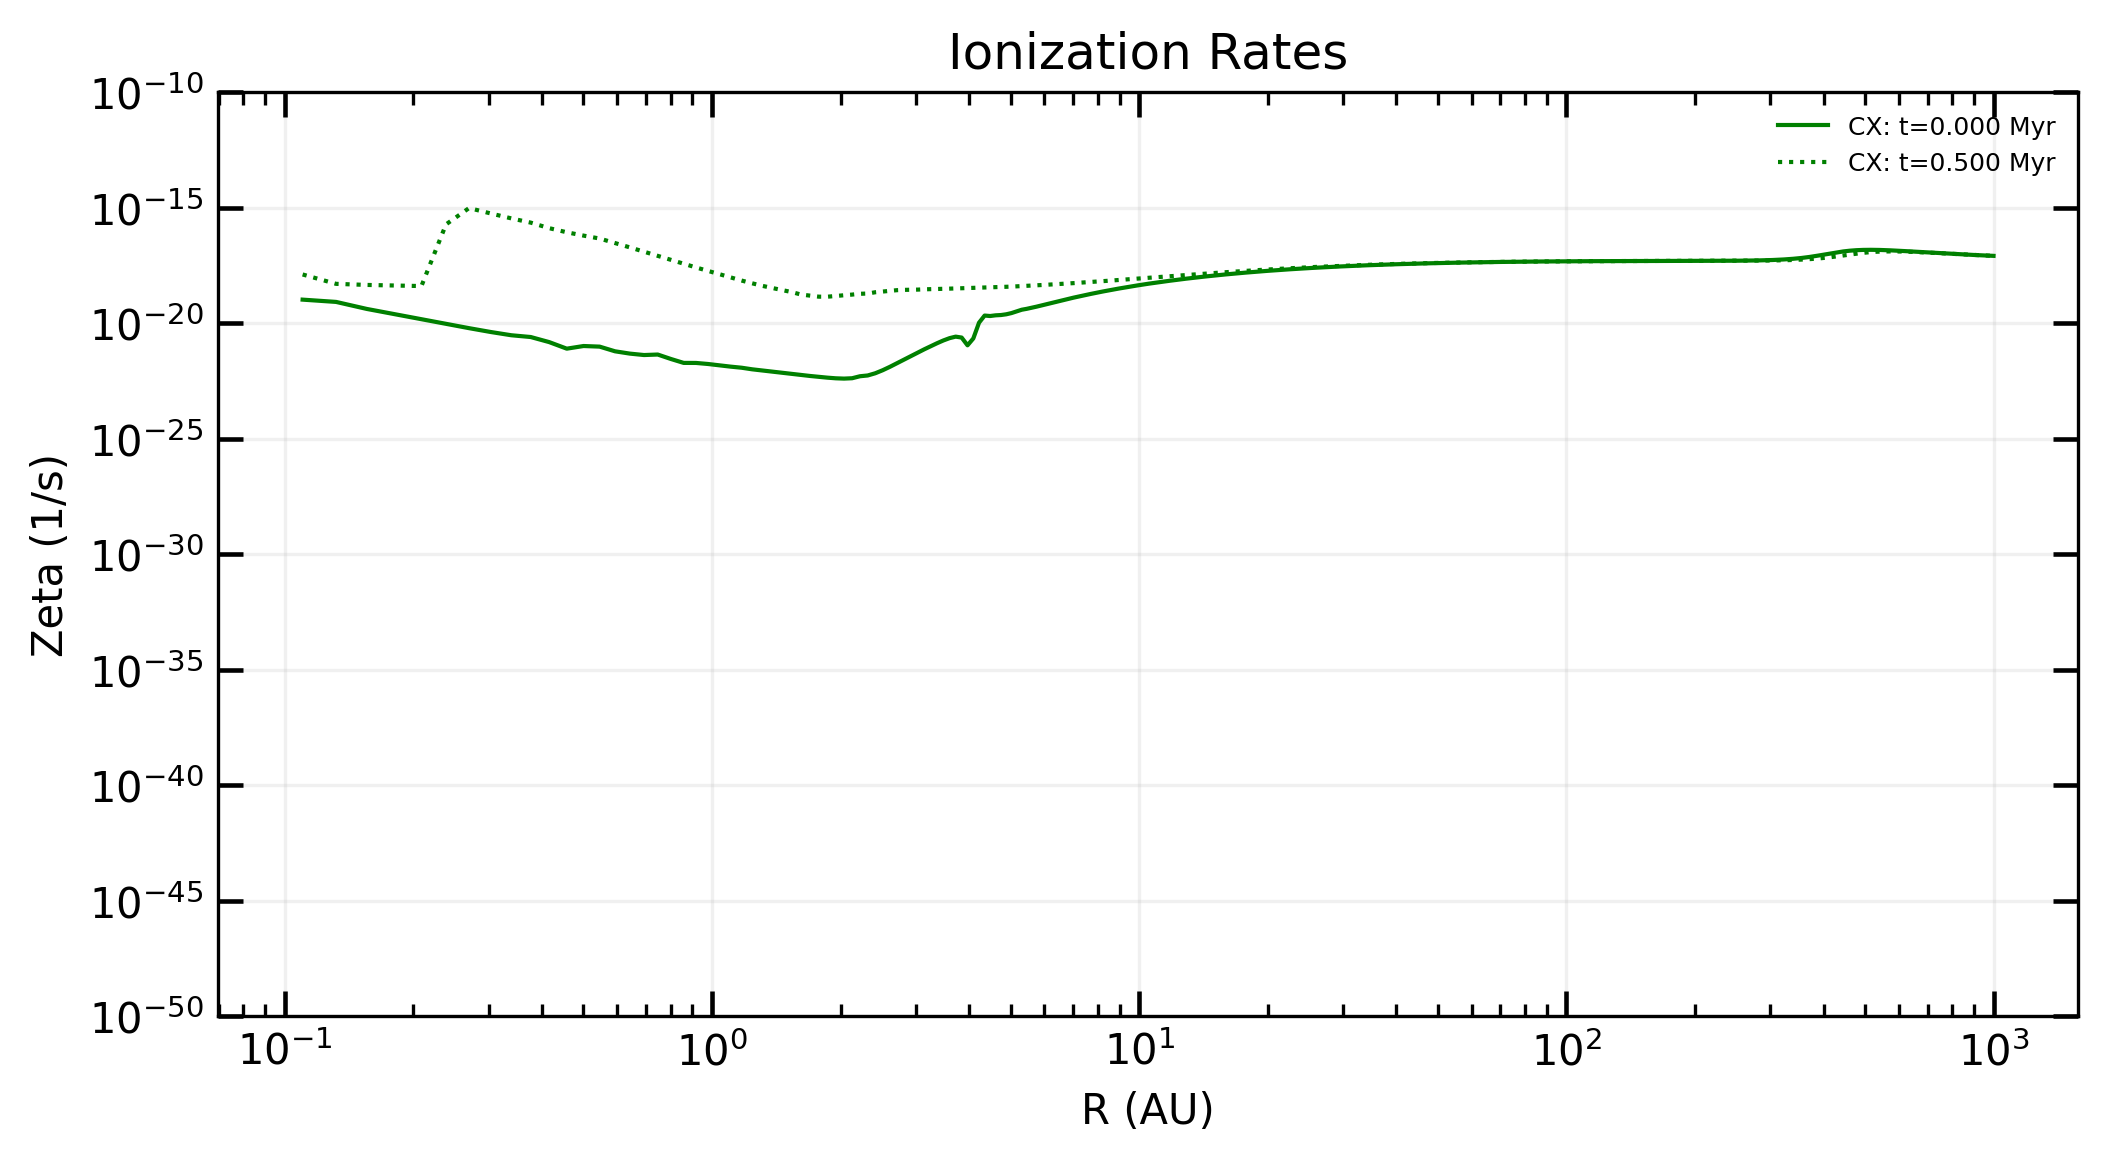

In [11]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
plt.title('Ionization Rates')
#ax.set_xlim(8,10)
ax.set_ylim(1e-50,1e-10)

ax.loglog(cxR, cxZeta[cxidx[0]], linestyle='solid', color='green', label=rf"CX: t={cxt[cxidx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxZeta[cxidx[-1]], linestyle='dotted', color='green', label=rf"CX: t={cxt[cxidx[-1]]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

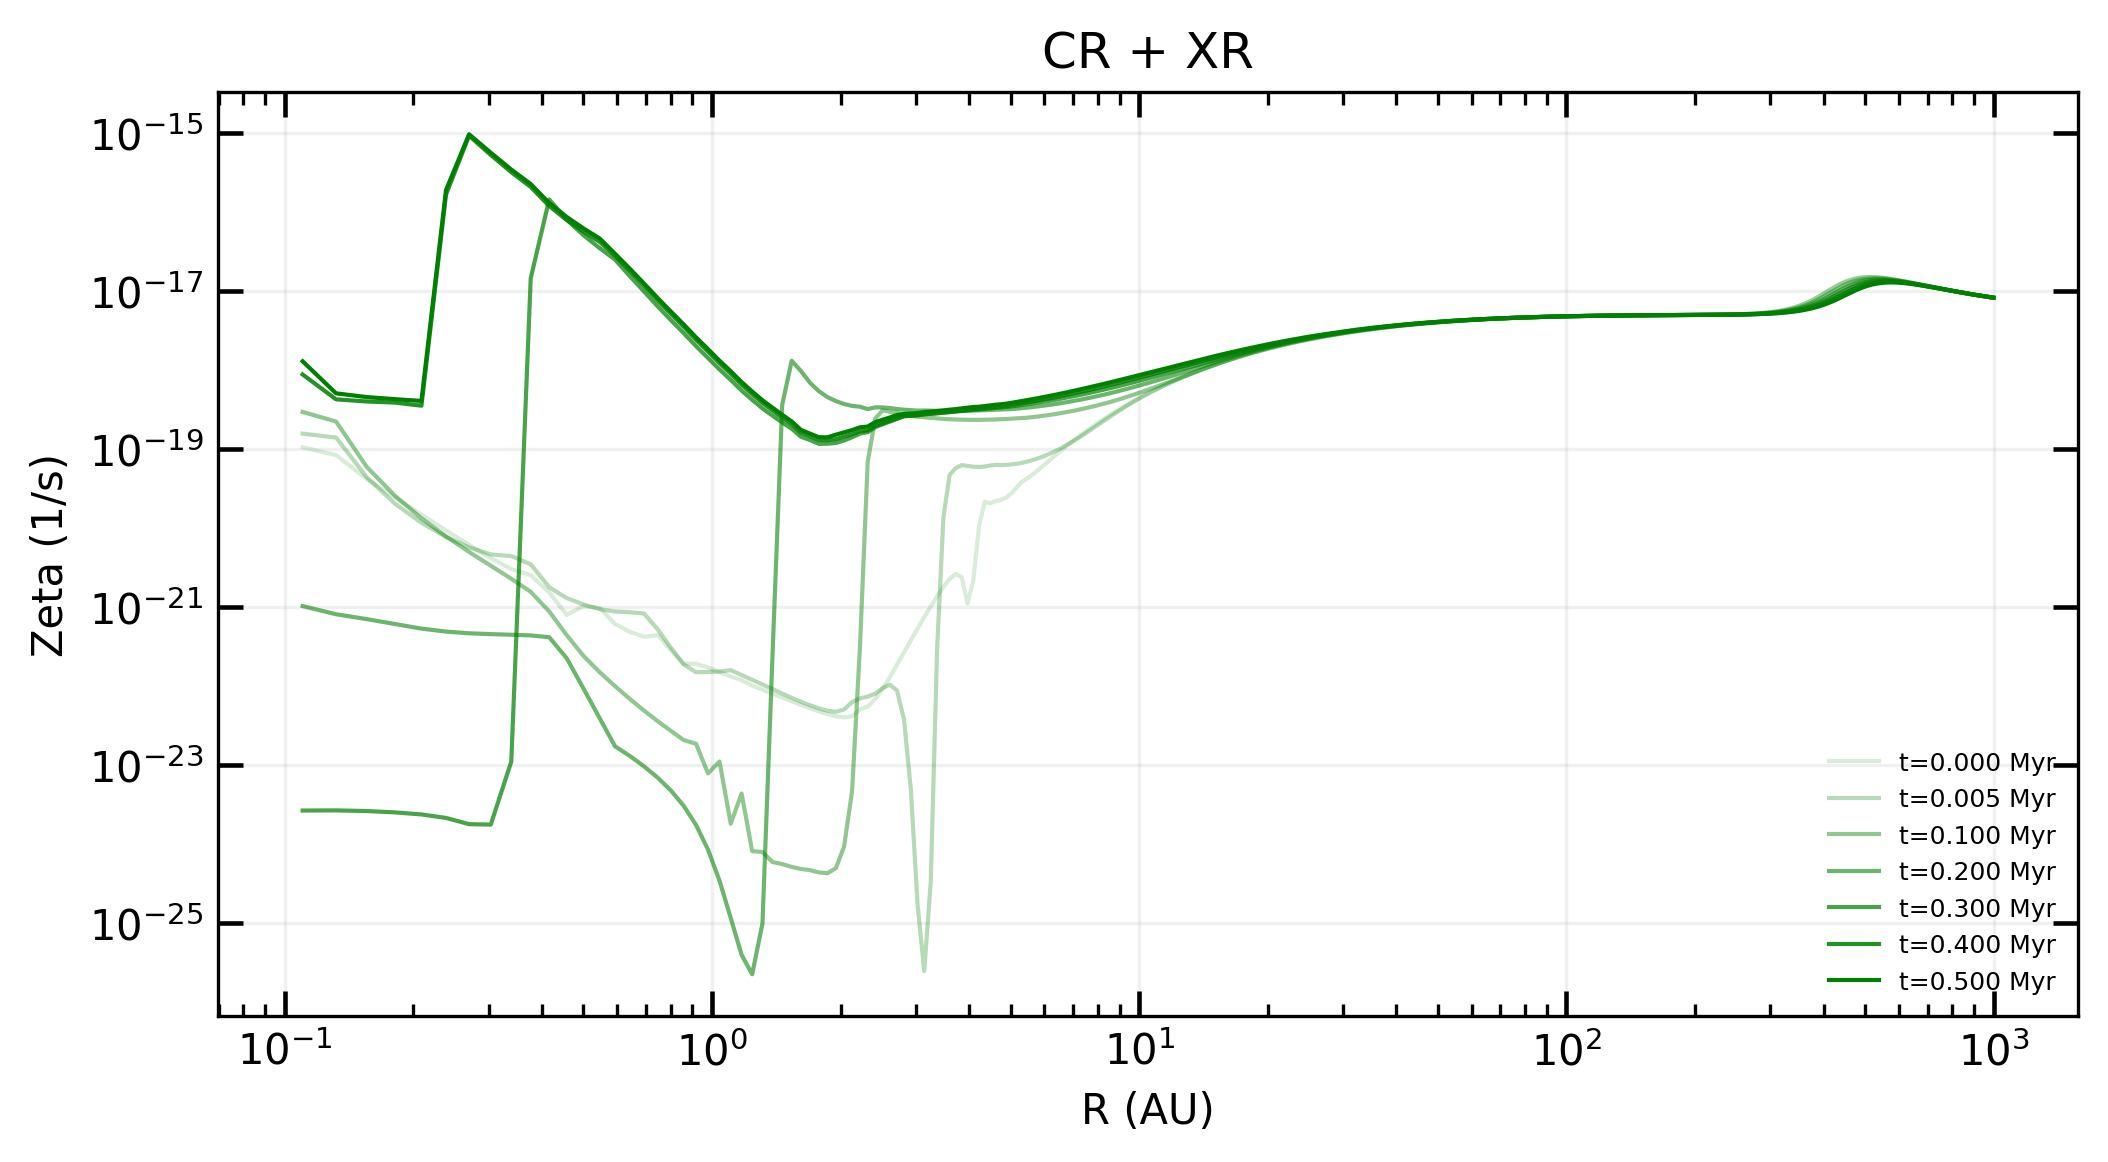

In [12]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
plt.title('CR + XR')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = cxR
ydata = cxZeta
for a_i, i in enumerate(cxidx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"t={cxt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

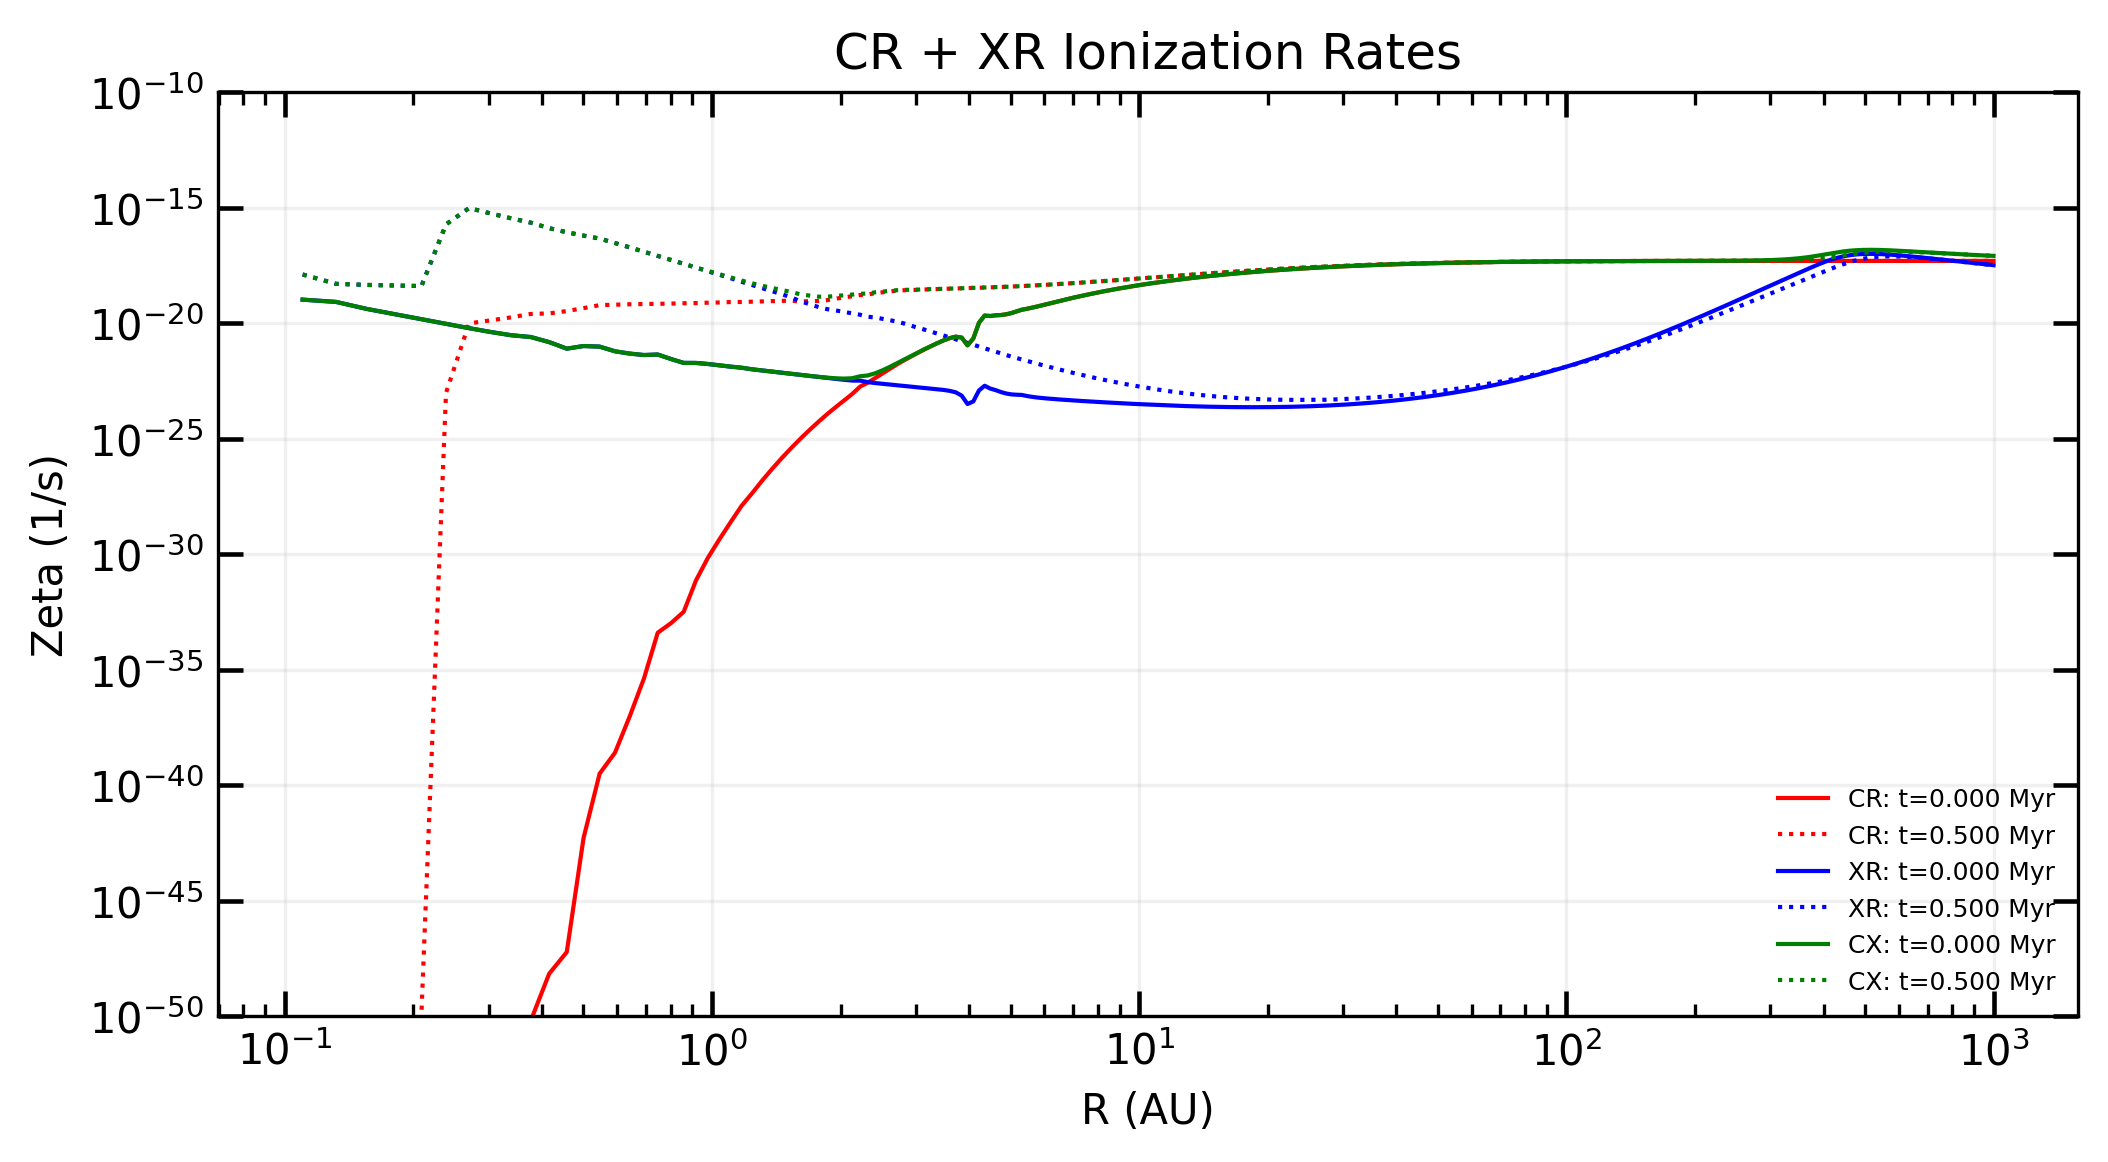

In [14]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
plt.title('CR + XR Ionization Rates')
#ax.set_xlim(8,10)
ax.set_ylim(1e-50,1e-10)

ax.loglog(cxR, cxZetaCR[cxidx[0]], linestyle='solid', color='red', label=rf"CR: t={cxt[cxidx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxZetaCR[cxidx[-1]], linestyle='dotted', color='red', label=rf"CR: t={cxt[cxidx[-1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxZetaXR[cxidx[0]], linestyle='solid', color='blue', label=rf"XR: t={cxt[cxidx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxZetaXR[cxidx[-1]], linestyle='dotted', color='blue', label=rf"XR: t={cxt[cxidx[-1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxZeta[cxidx[0]], linestyle='solid', color='green', label=rf"CX: t={cxt[cxidx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxZeta[cxidx[-1]], linestyle='dotted', color='green', label=rf"CX: t={cxt[cxidx[-1]]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

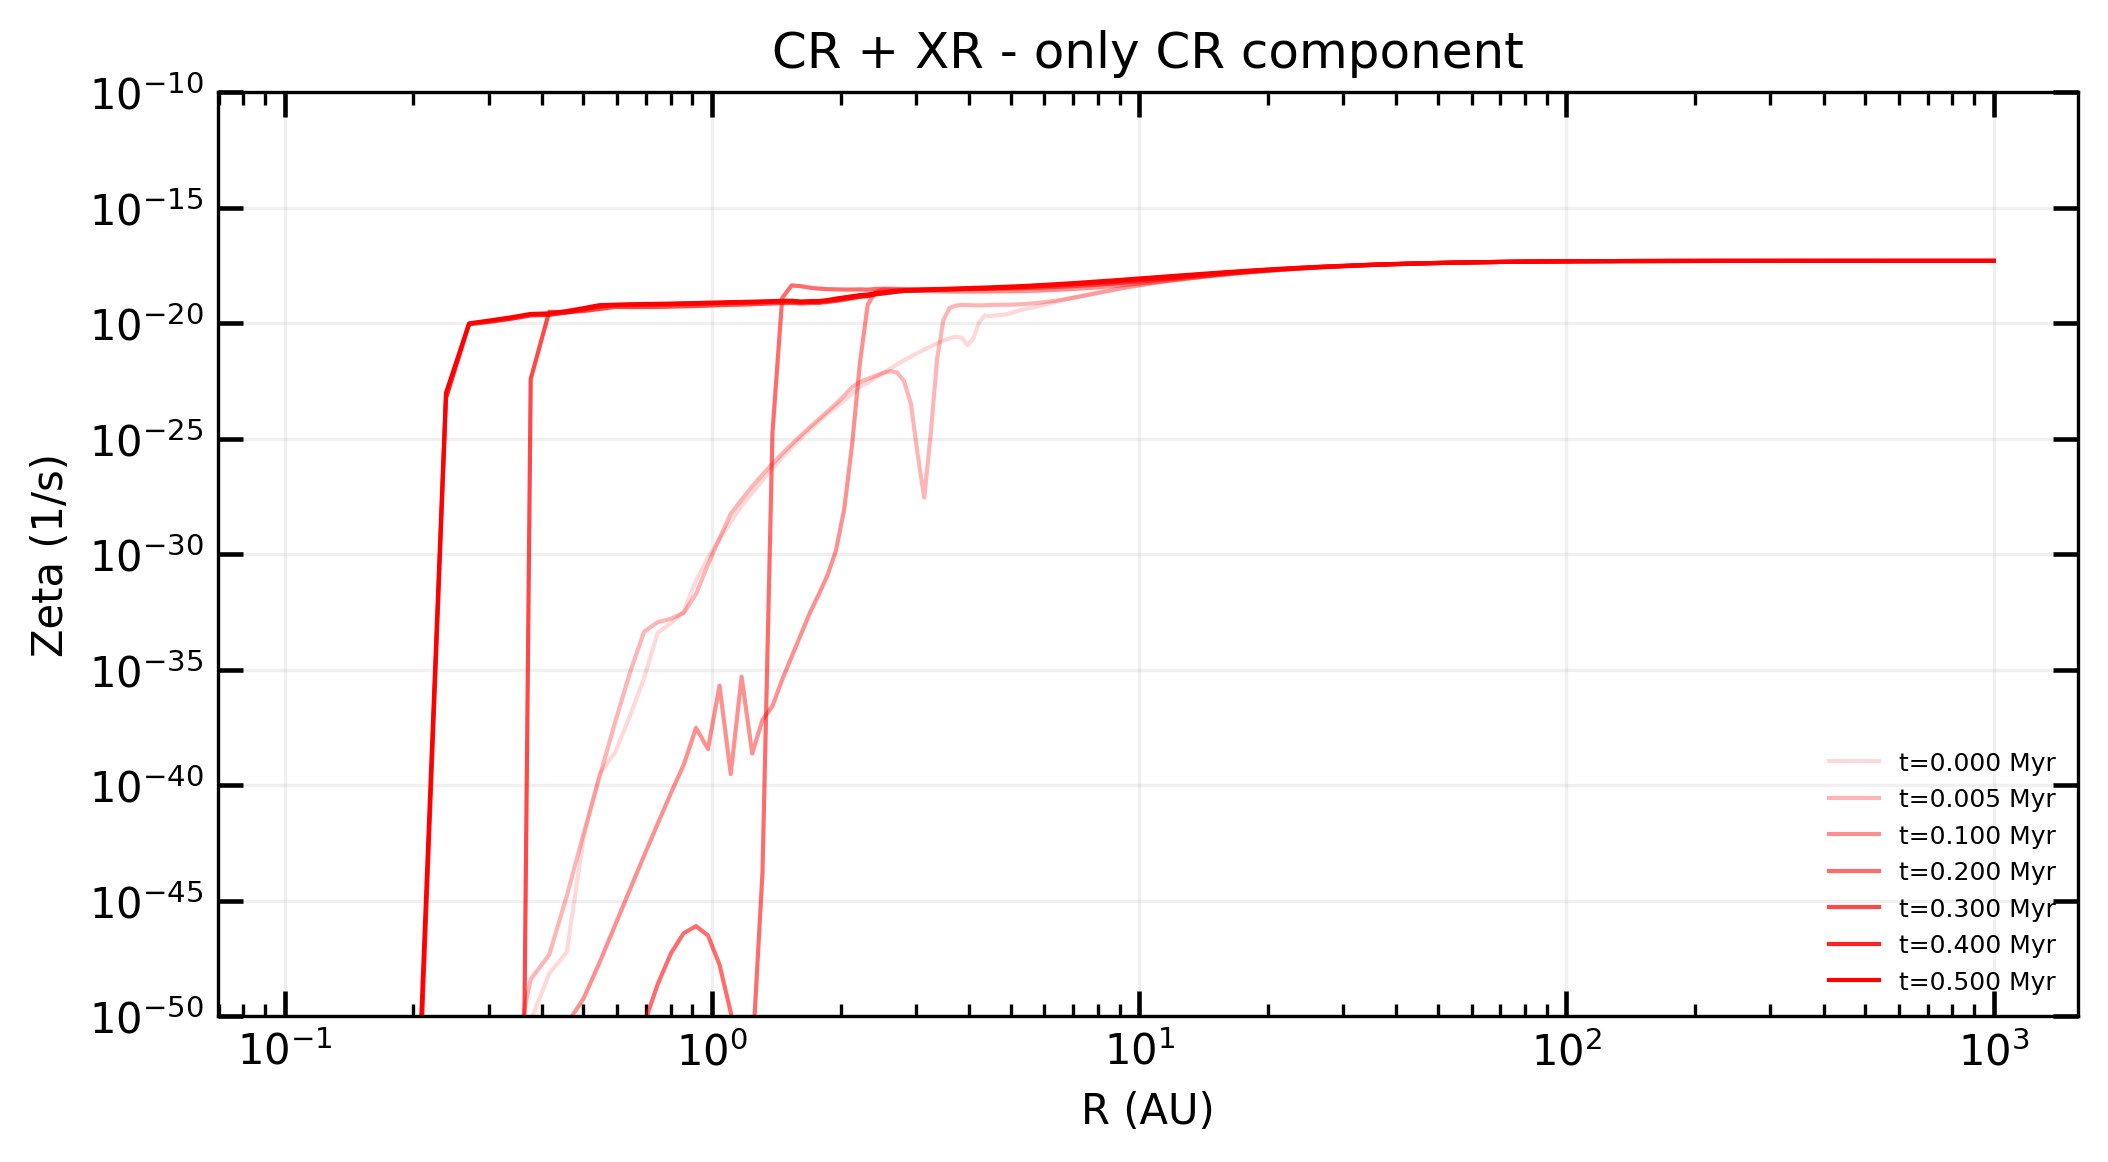

In [15]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
plt.title('CR + XR - only CR component')
#ax.set_xlim(8,10)
ax.set_ylim(1e-50,1e-10)

xdata = cxR
ydata = cxZetaCR
for a_i, i in enumerate(cxidx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={cxt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

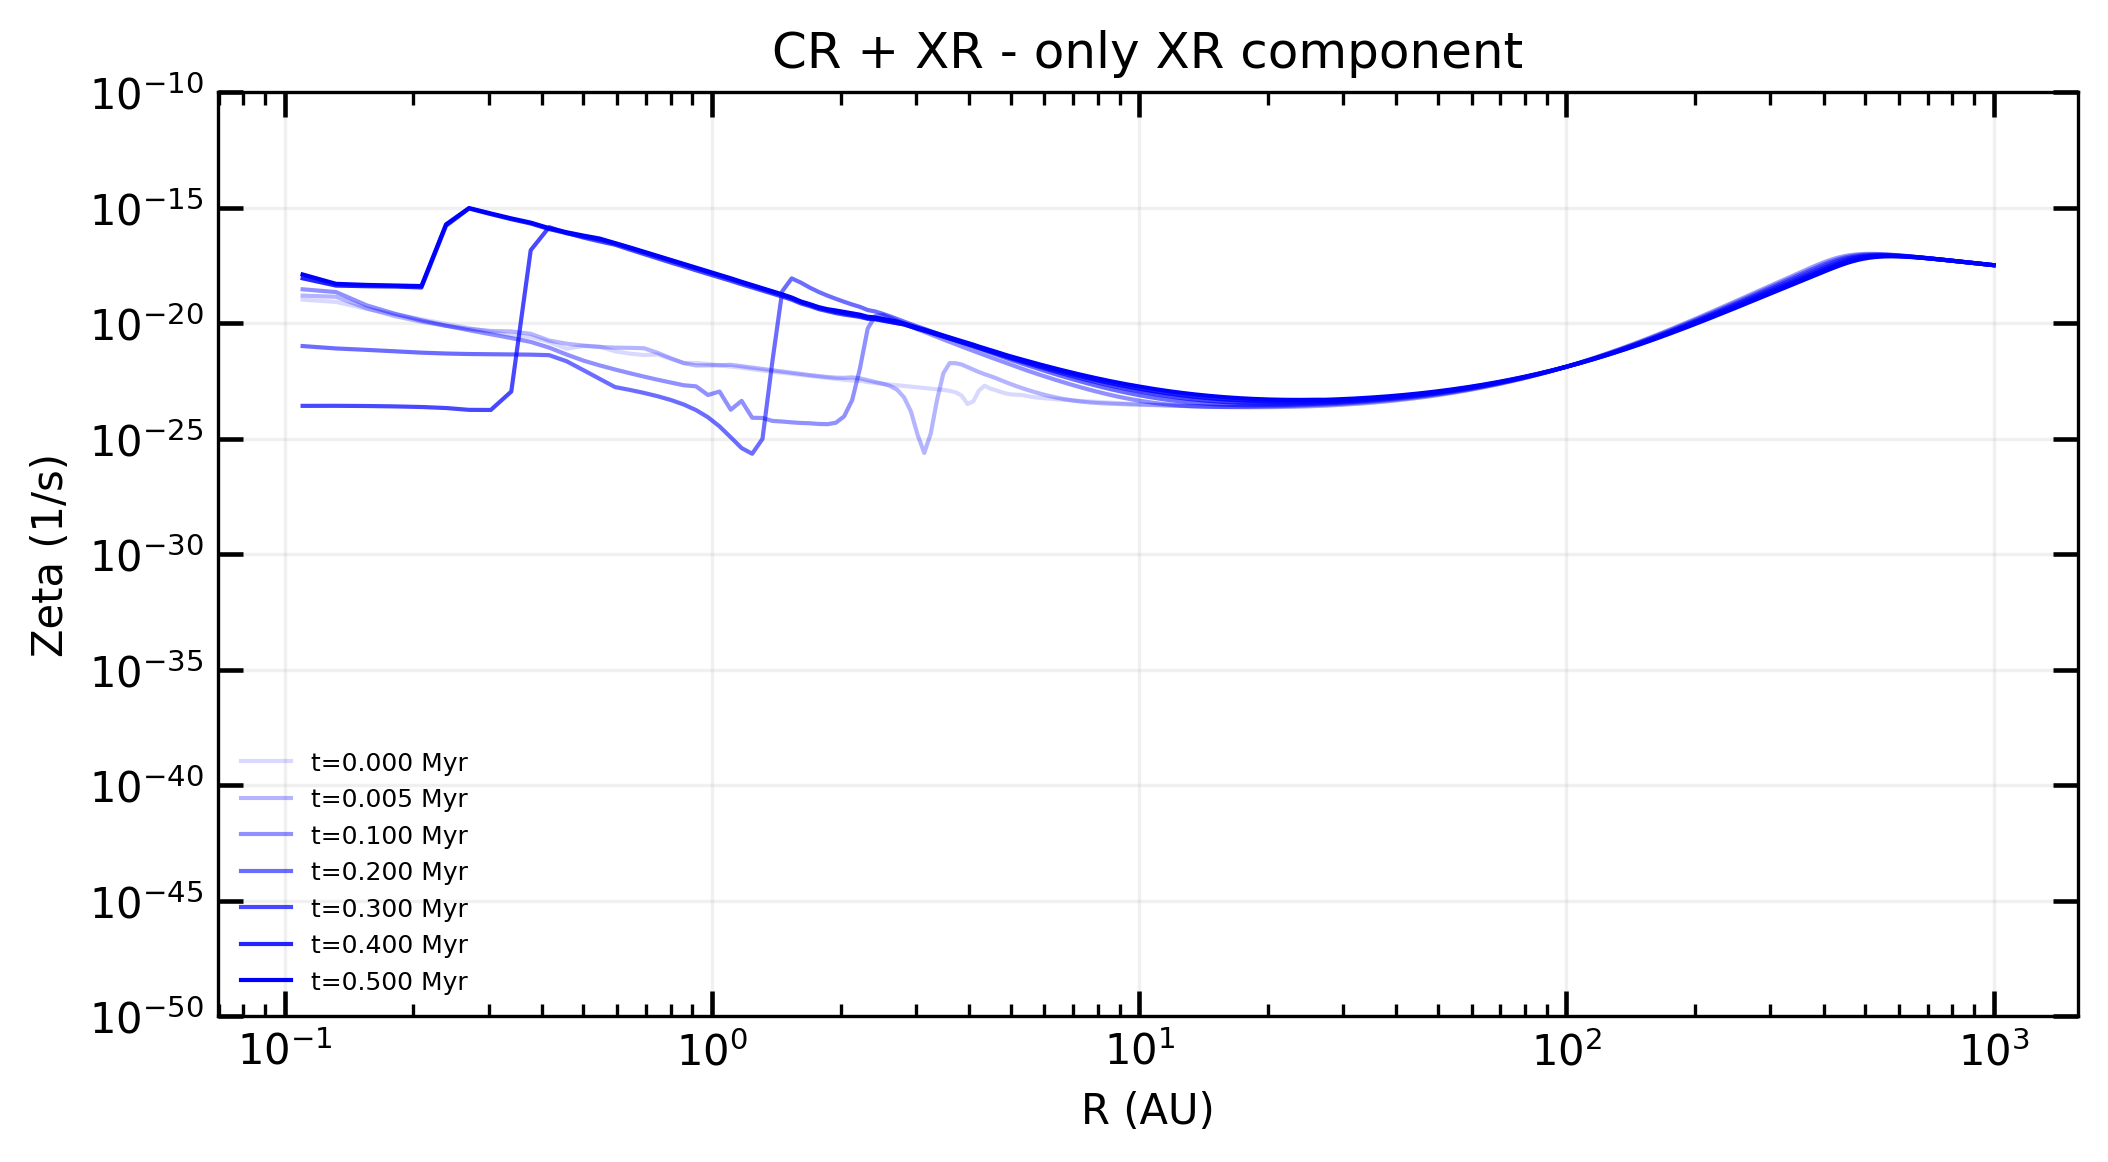

In [17]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
plt.title('CR + XR - only XR component')
#ax.set_xlim(8,10)
ax.set_ylim(1e-50,1e-10)

xdata = cxR
ydata = cxZetaXR
for a_i, i in enumerate(cxidx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='blue', alpha=alphas[a_i],
                label=rf"t={cxt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

# Deadzone Radius

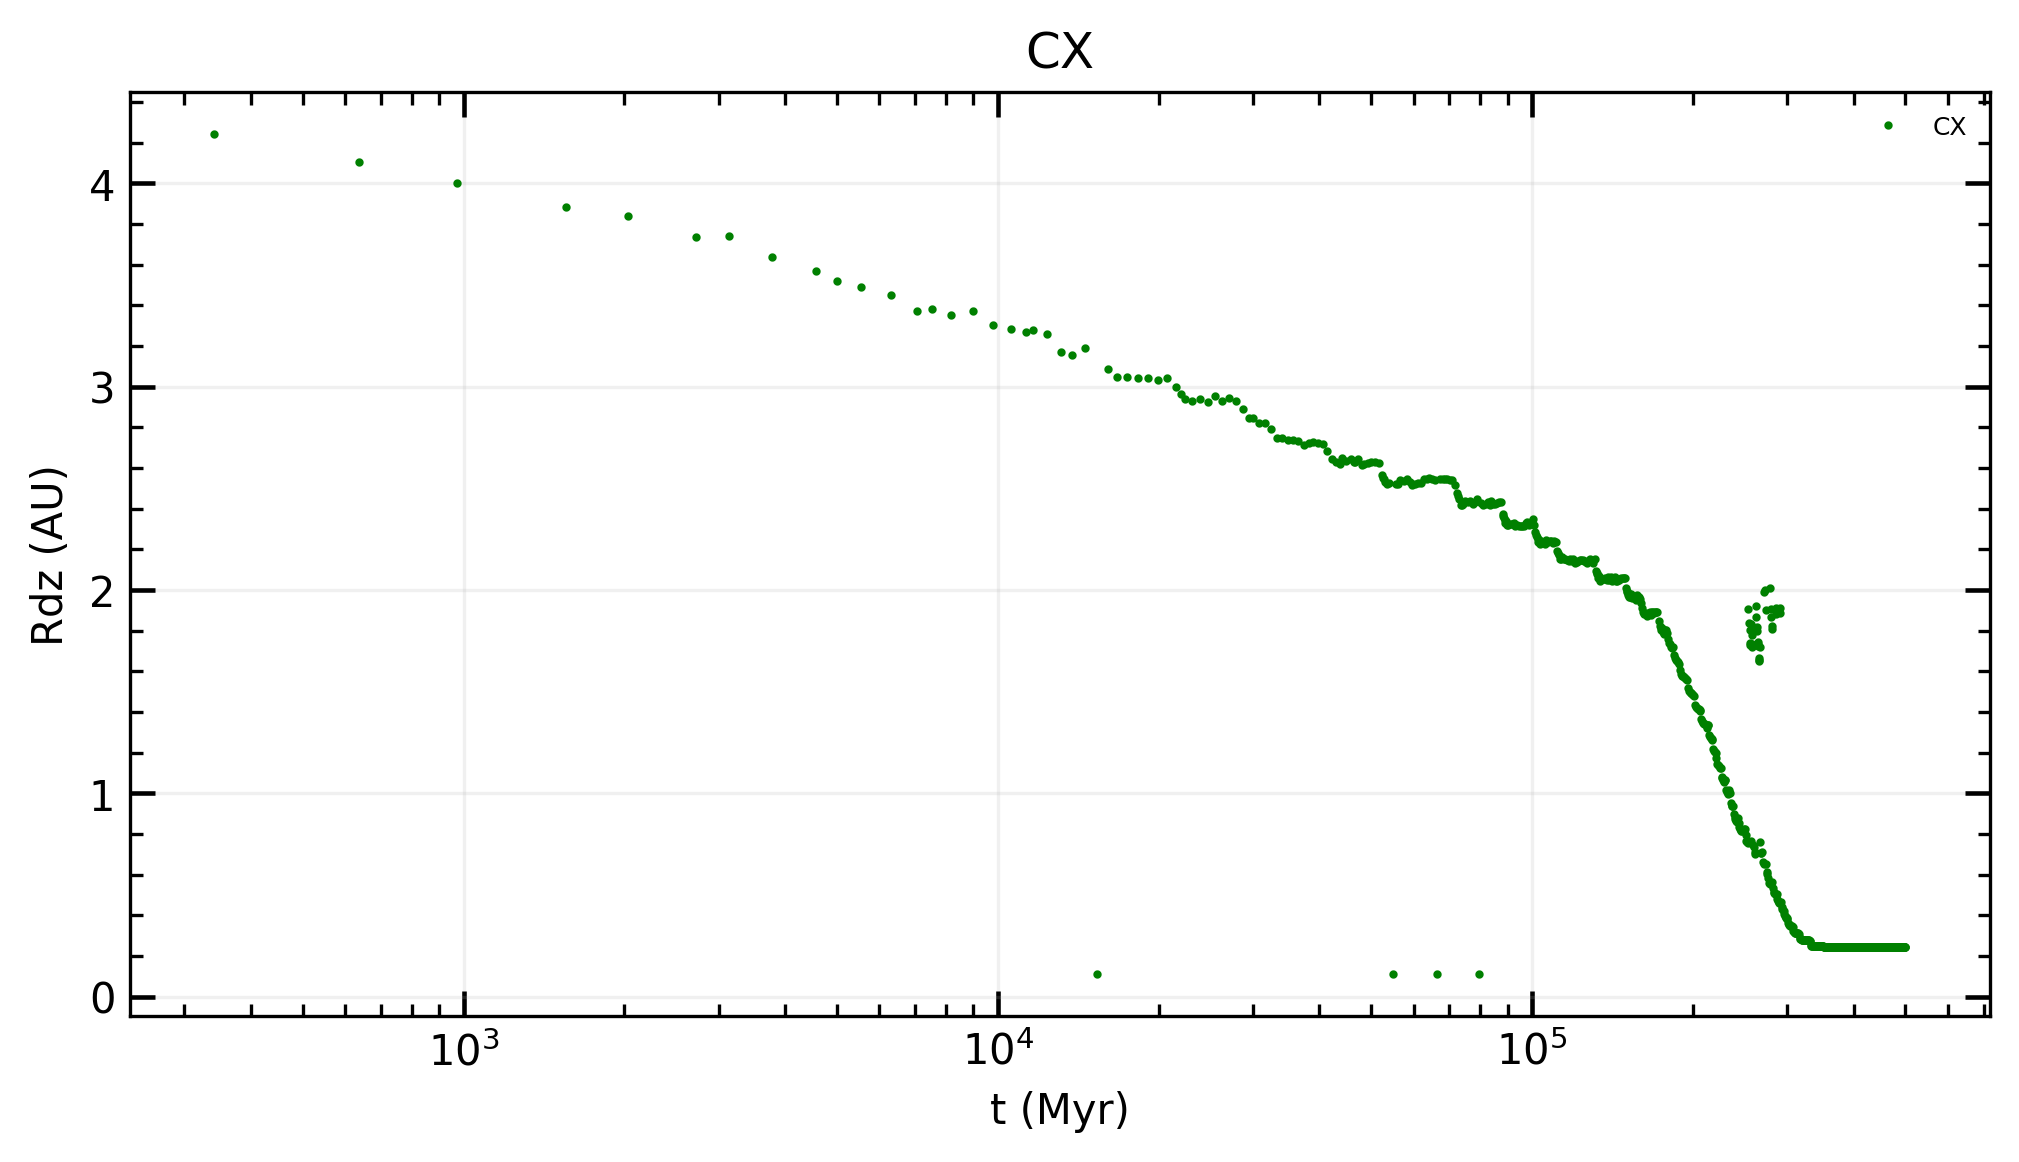

In [18]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('t (Myr)')
ax.set_ylabel('Rdz (AU)')
plt.title('CX')
#ax.set_xlim(8,10)
#ax.set_ylim(1e-50,1e-15)

ax.semilogx(cxt, cxRdz, '.g', label=rf"CX", ms = 2.0)

ax.legend(frameon=False, fontsize=6, loc="best")

# xe electron fraction

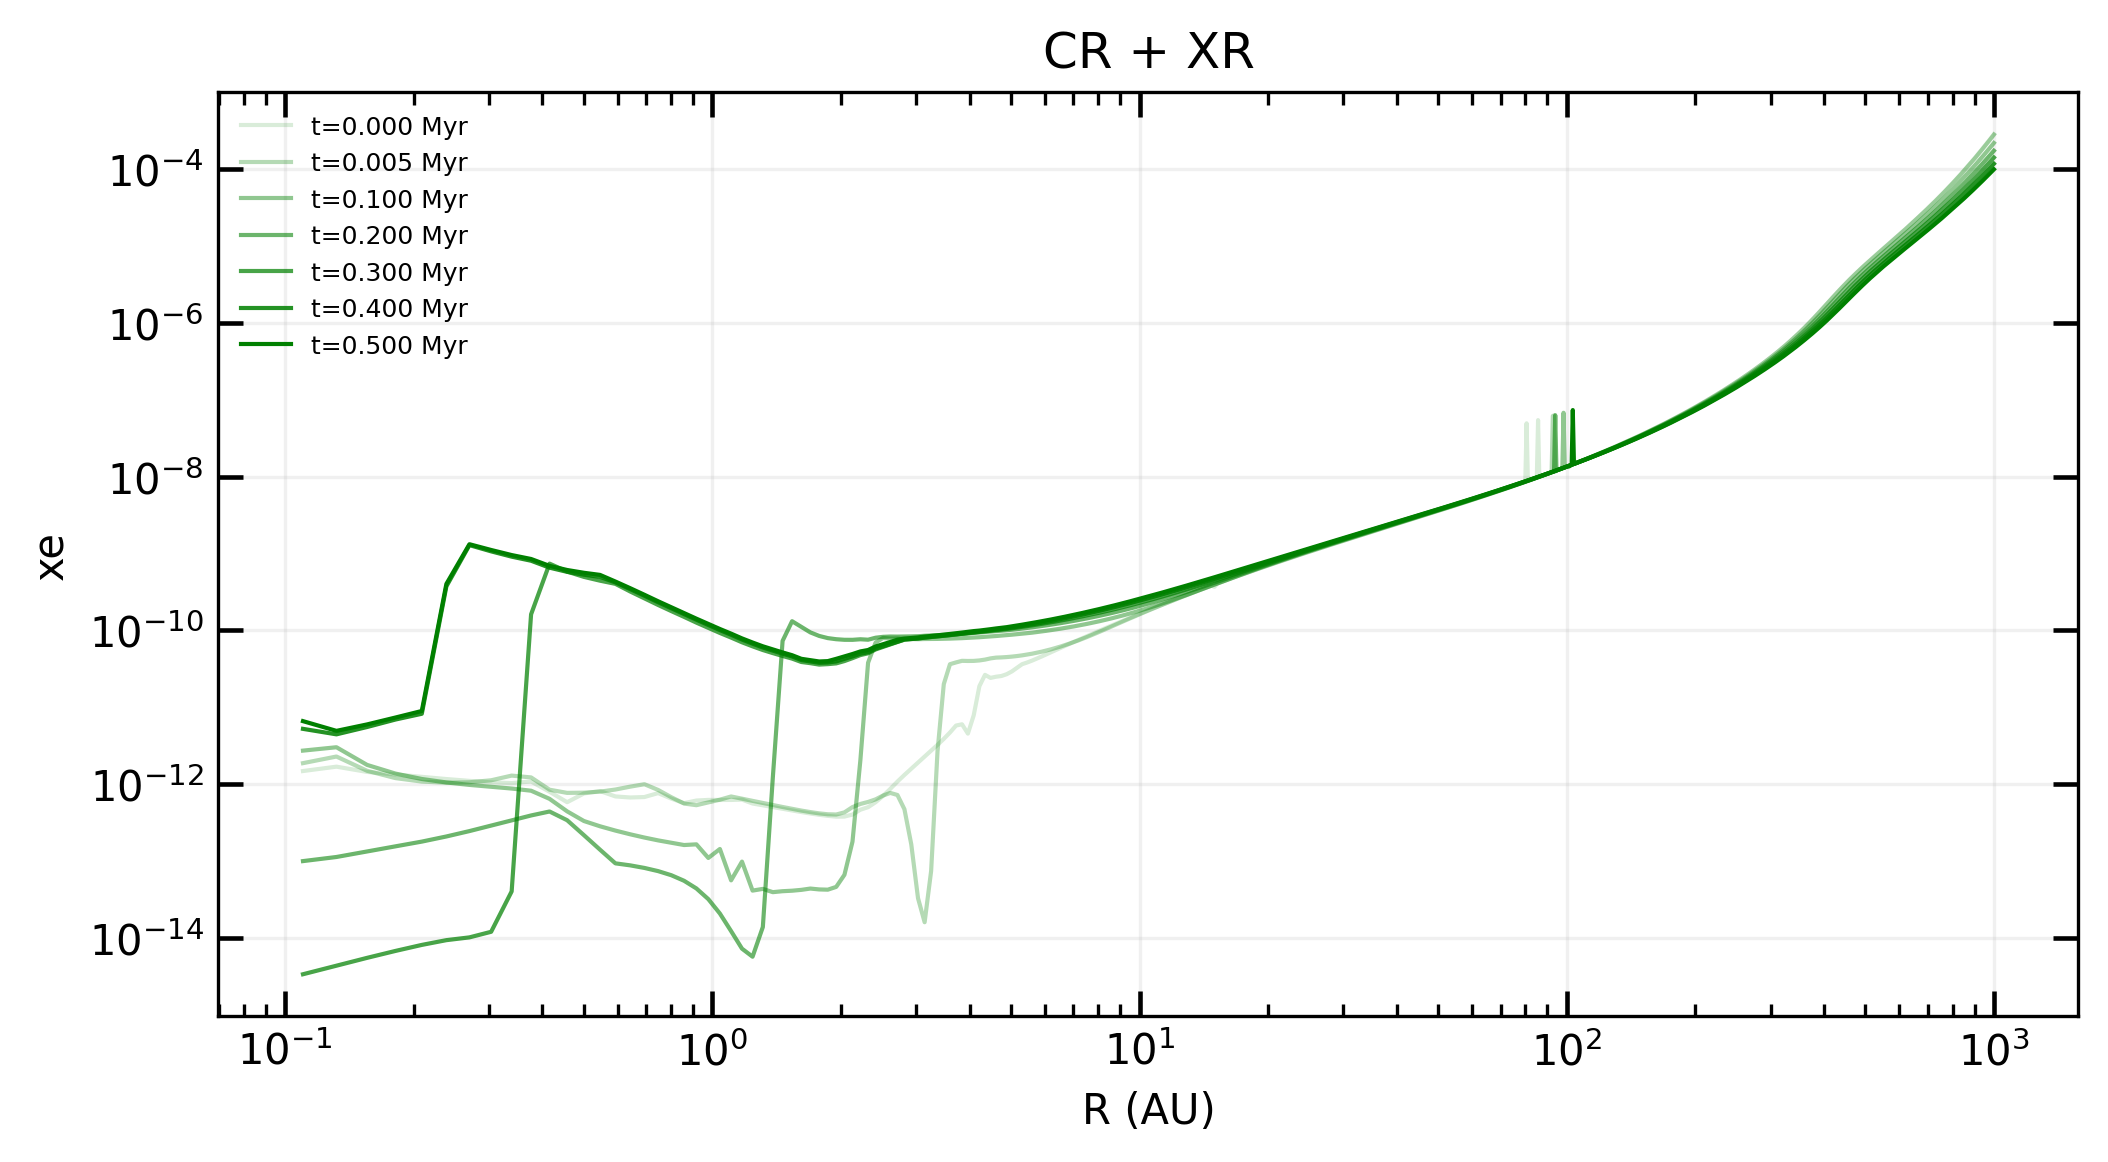

In [19]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('xe')
plt.title('CR + XR')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = cxR
ydata = cxxe
for a_i, i in enumerate(cxidx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"t={cxt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

# Elsasser Number

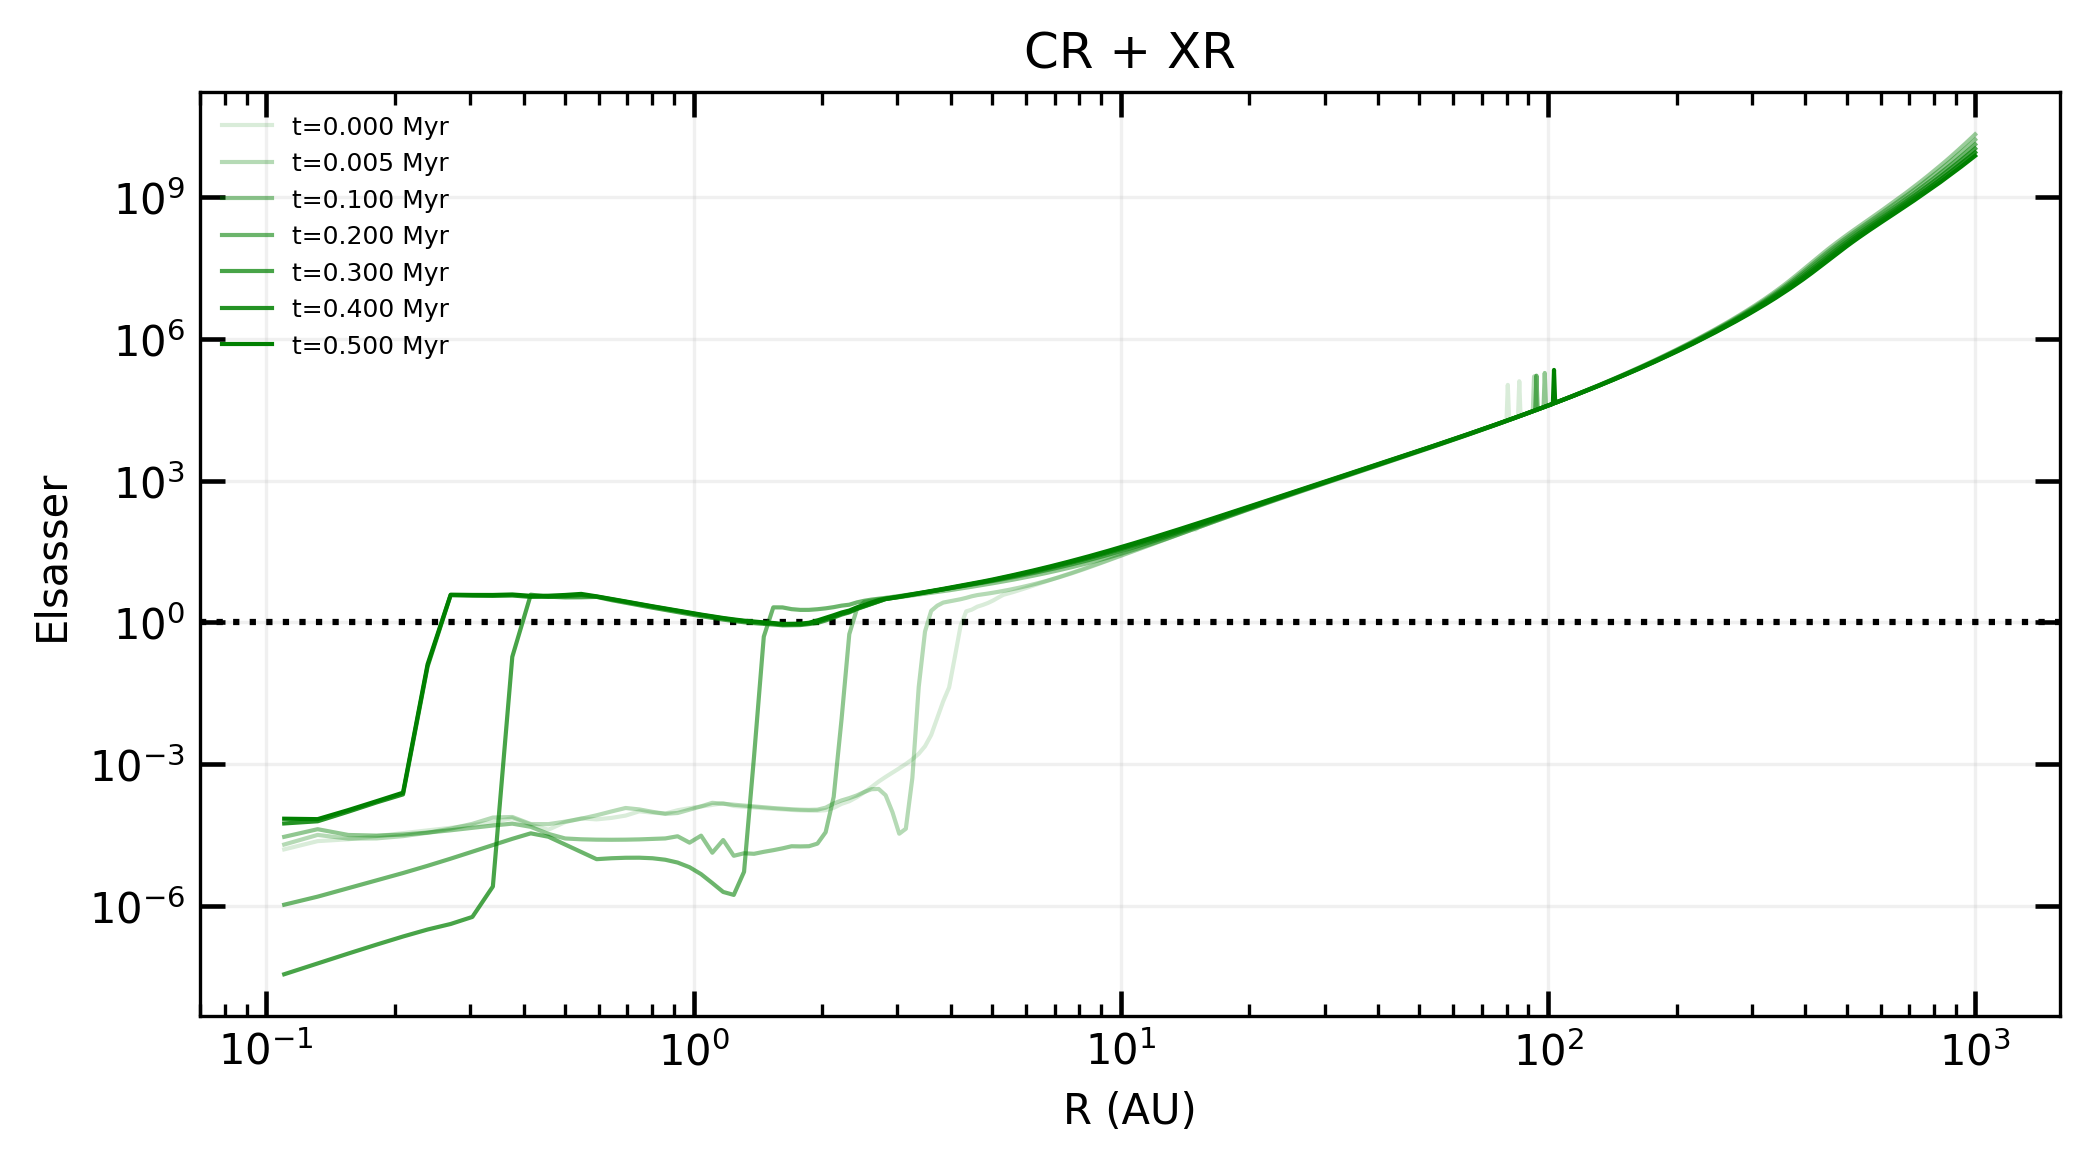

In [20]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Elsasser')
plt.title('CR + XR')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)
ax.axhline(y = 1.0, color = 'black', ls = 'dotted')

xdata = cxR
ydata = cxLam
for a_i, i in enumerate(cxidx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"t={cxt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

# eta Magnetic Diffusivity

# n density 

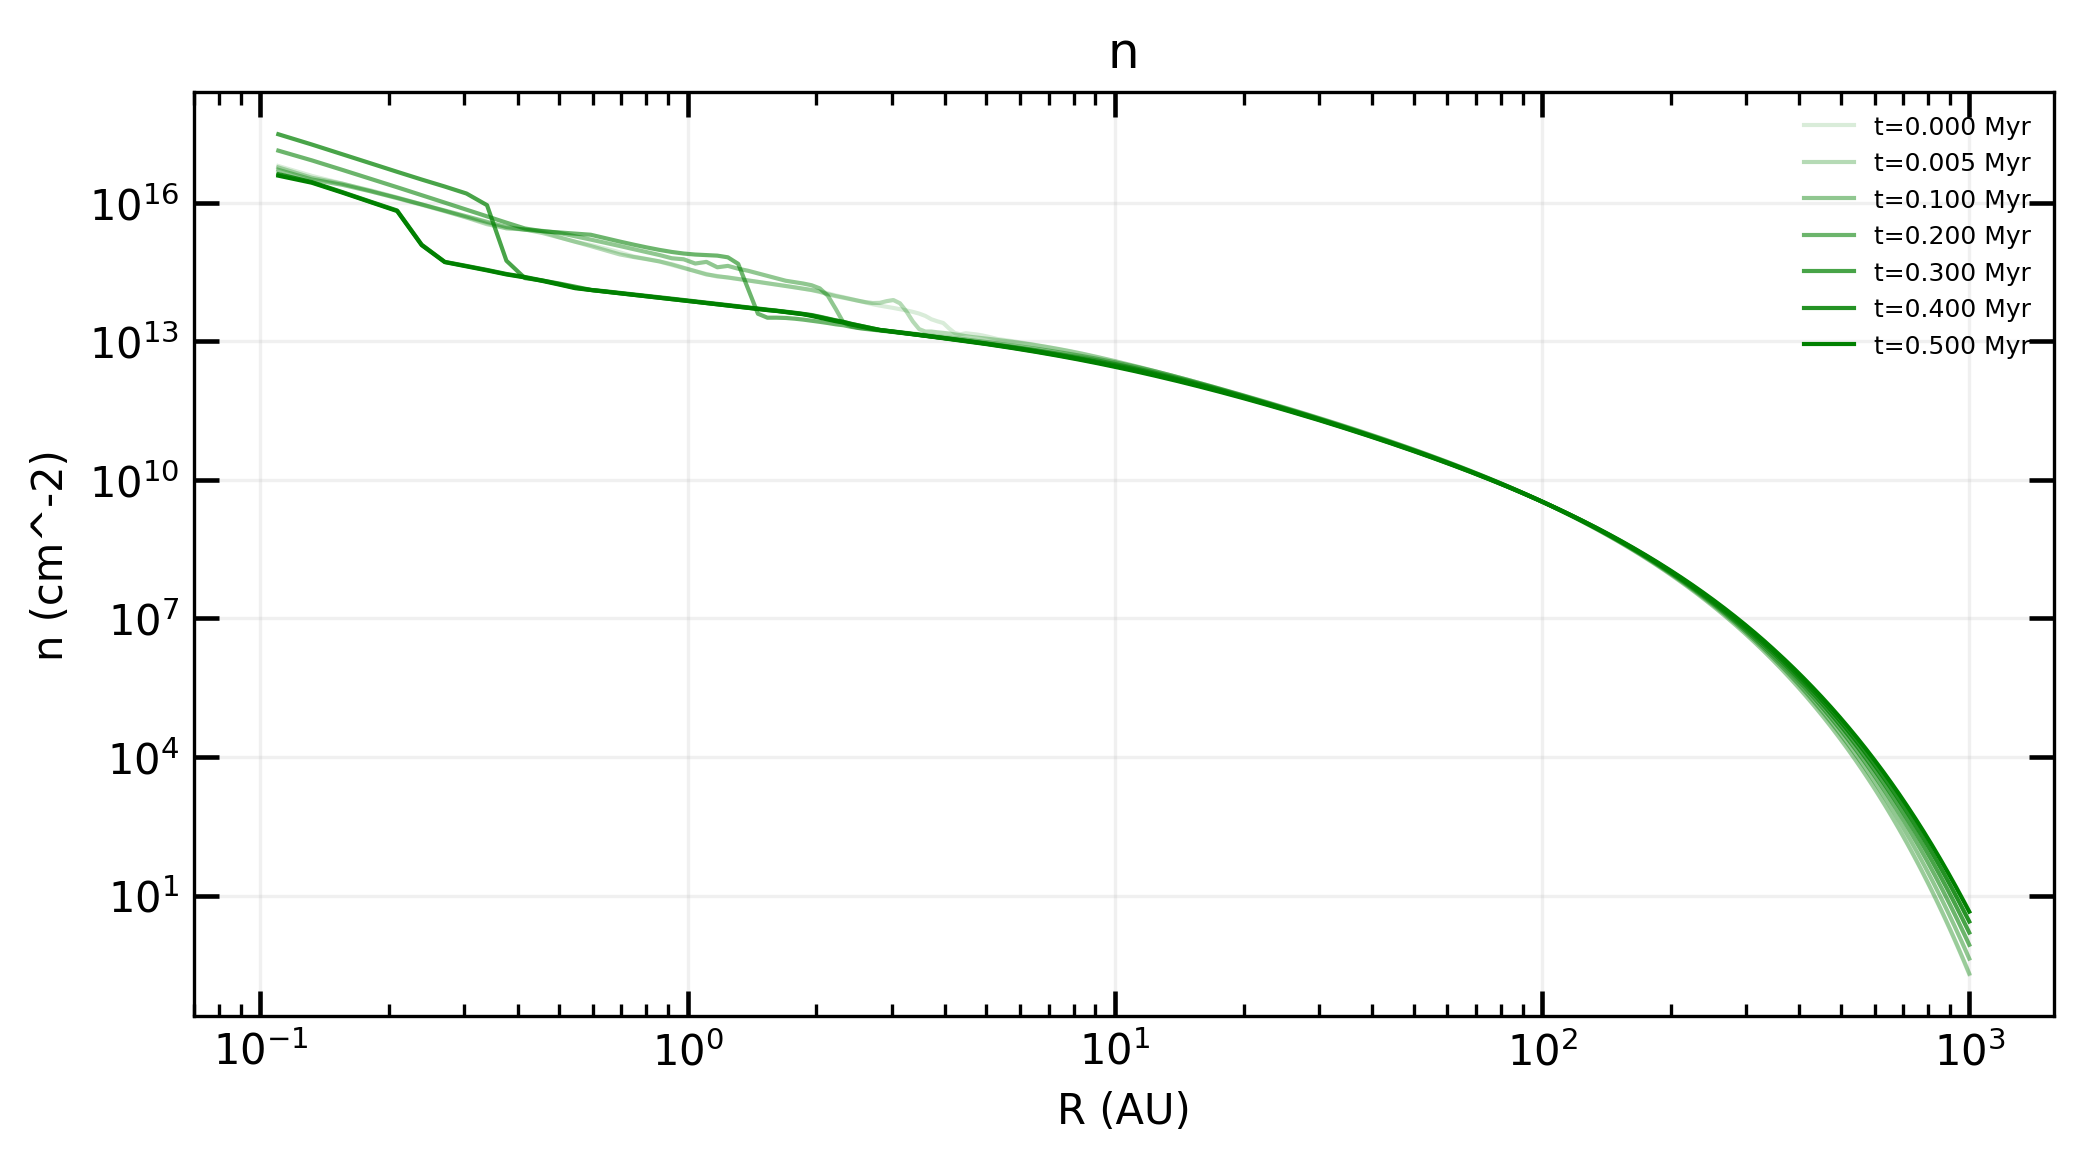

In [21]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('n (cm^-2)')
plt.title('n')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = cxR
ydata = cxn
for a_i, i in enumerate(cxidx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"t={cxt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

# Sigma

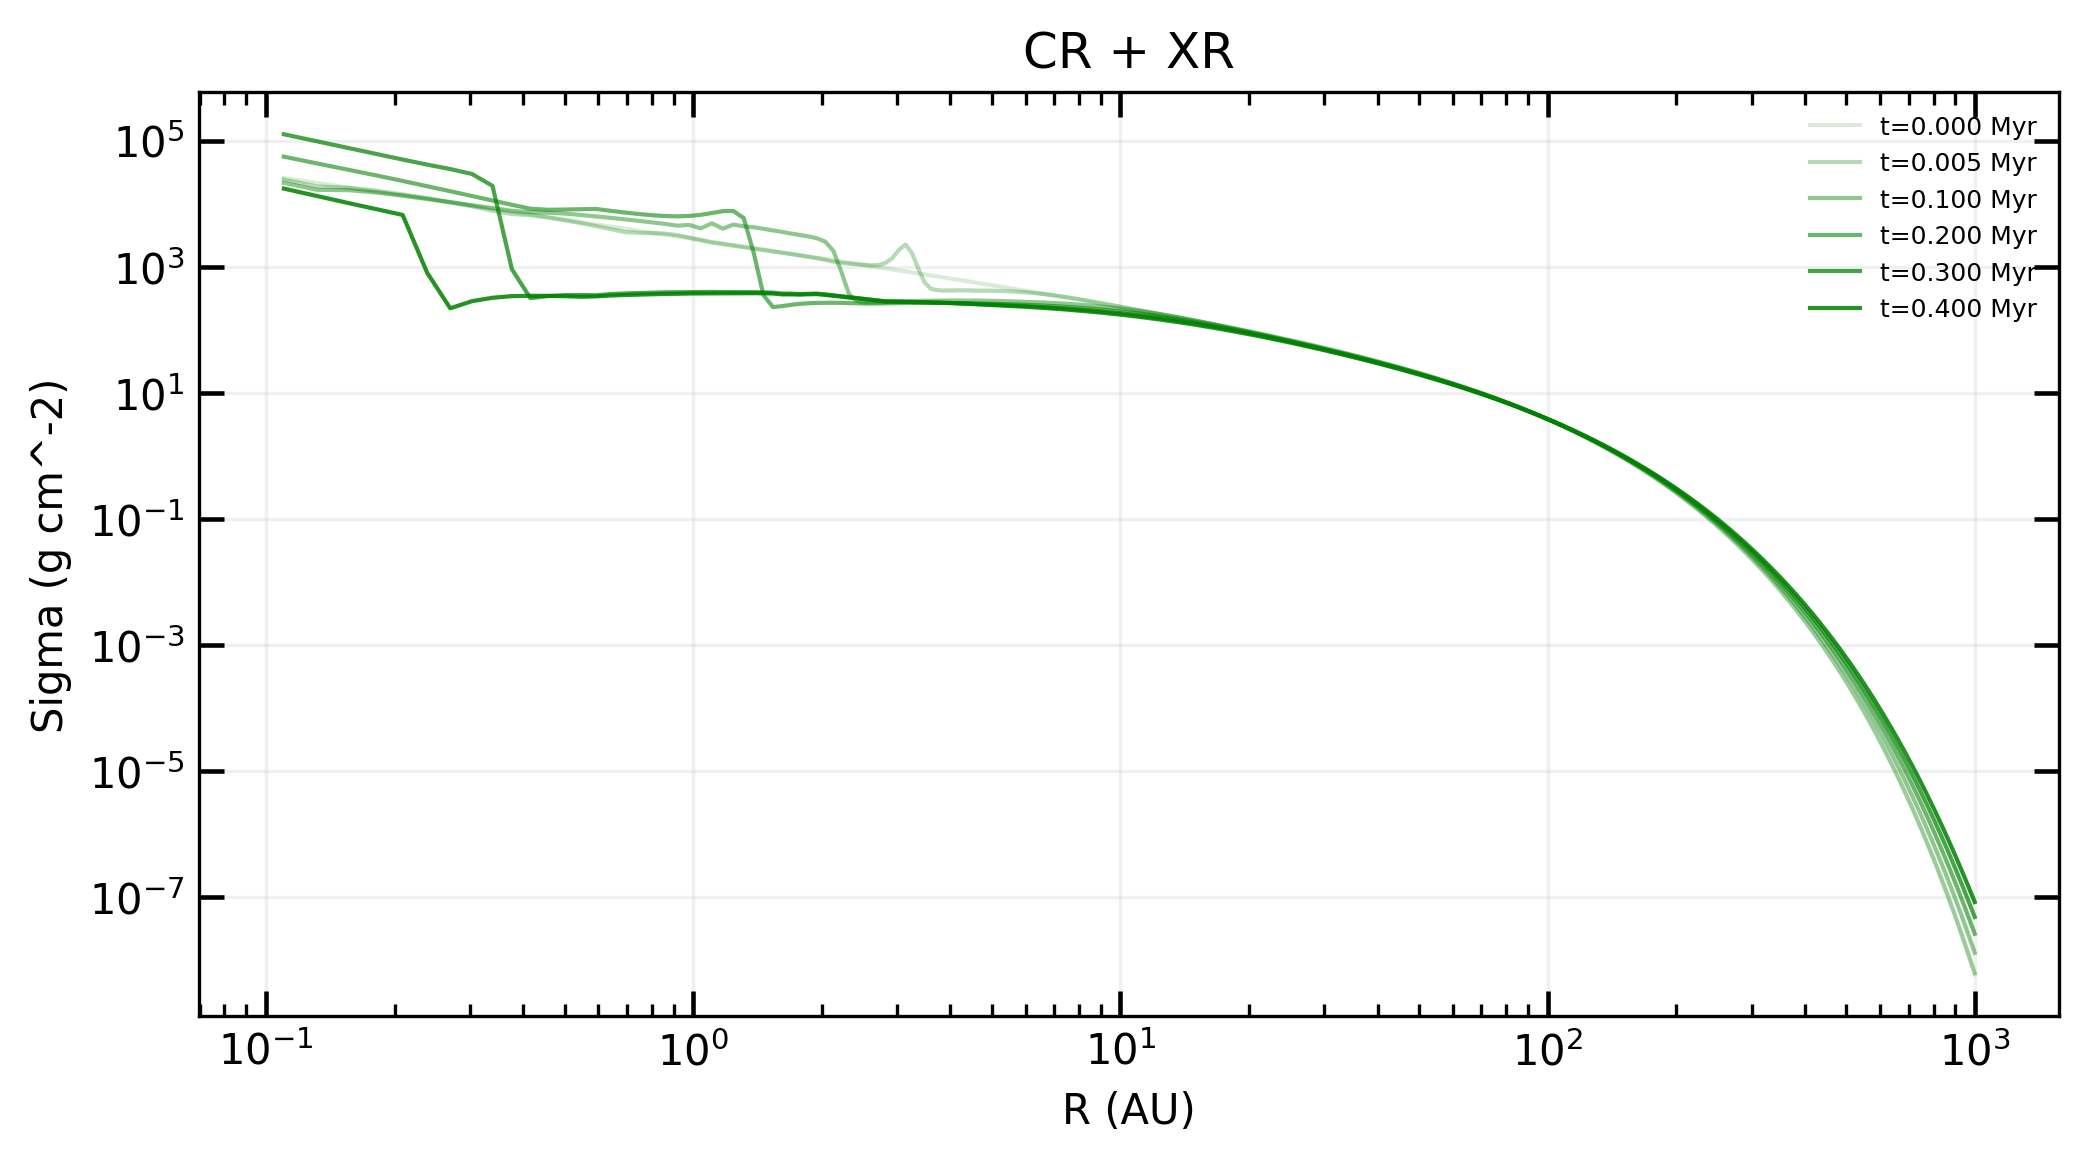

In [22]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Sigma (g cm^-2)')
plt.title('CR + XR')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = cxR
ydata = cxSigma_g
for a_i, i in enumerate(range(0,6)):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"t={cxtsnap[i]:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

# alpha

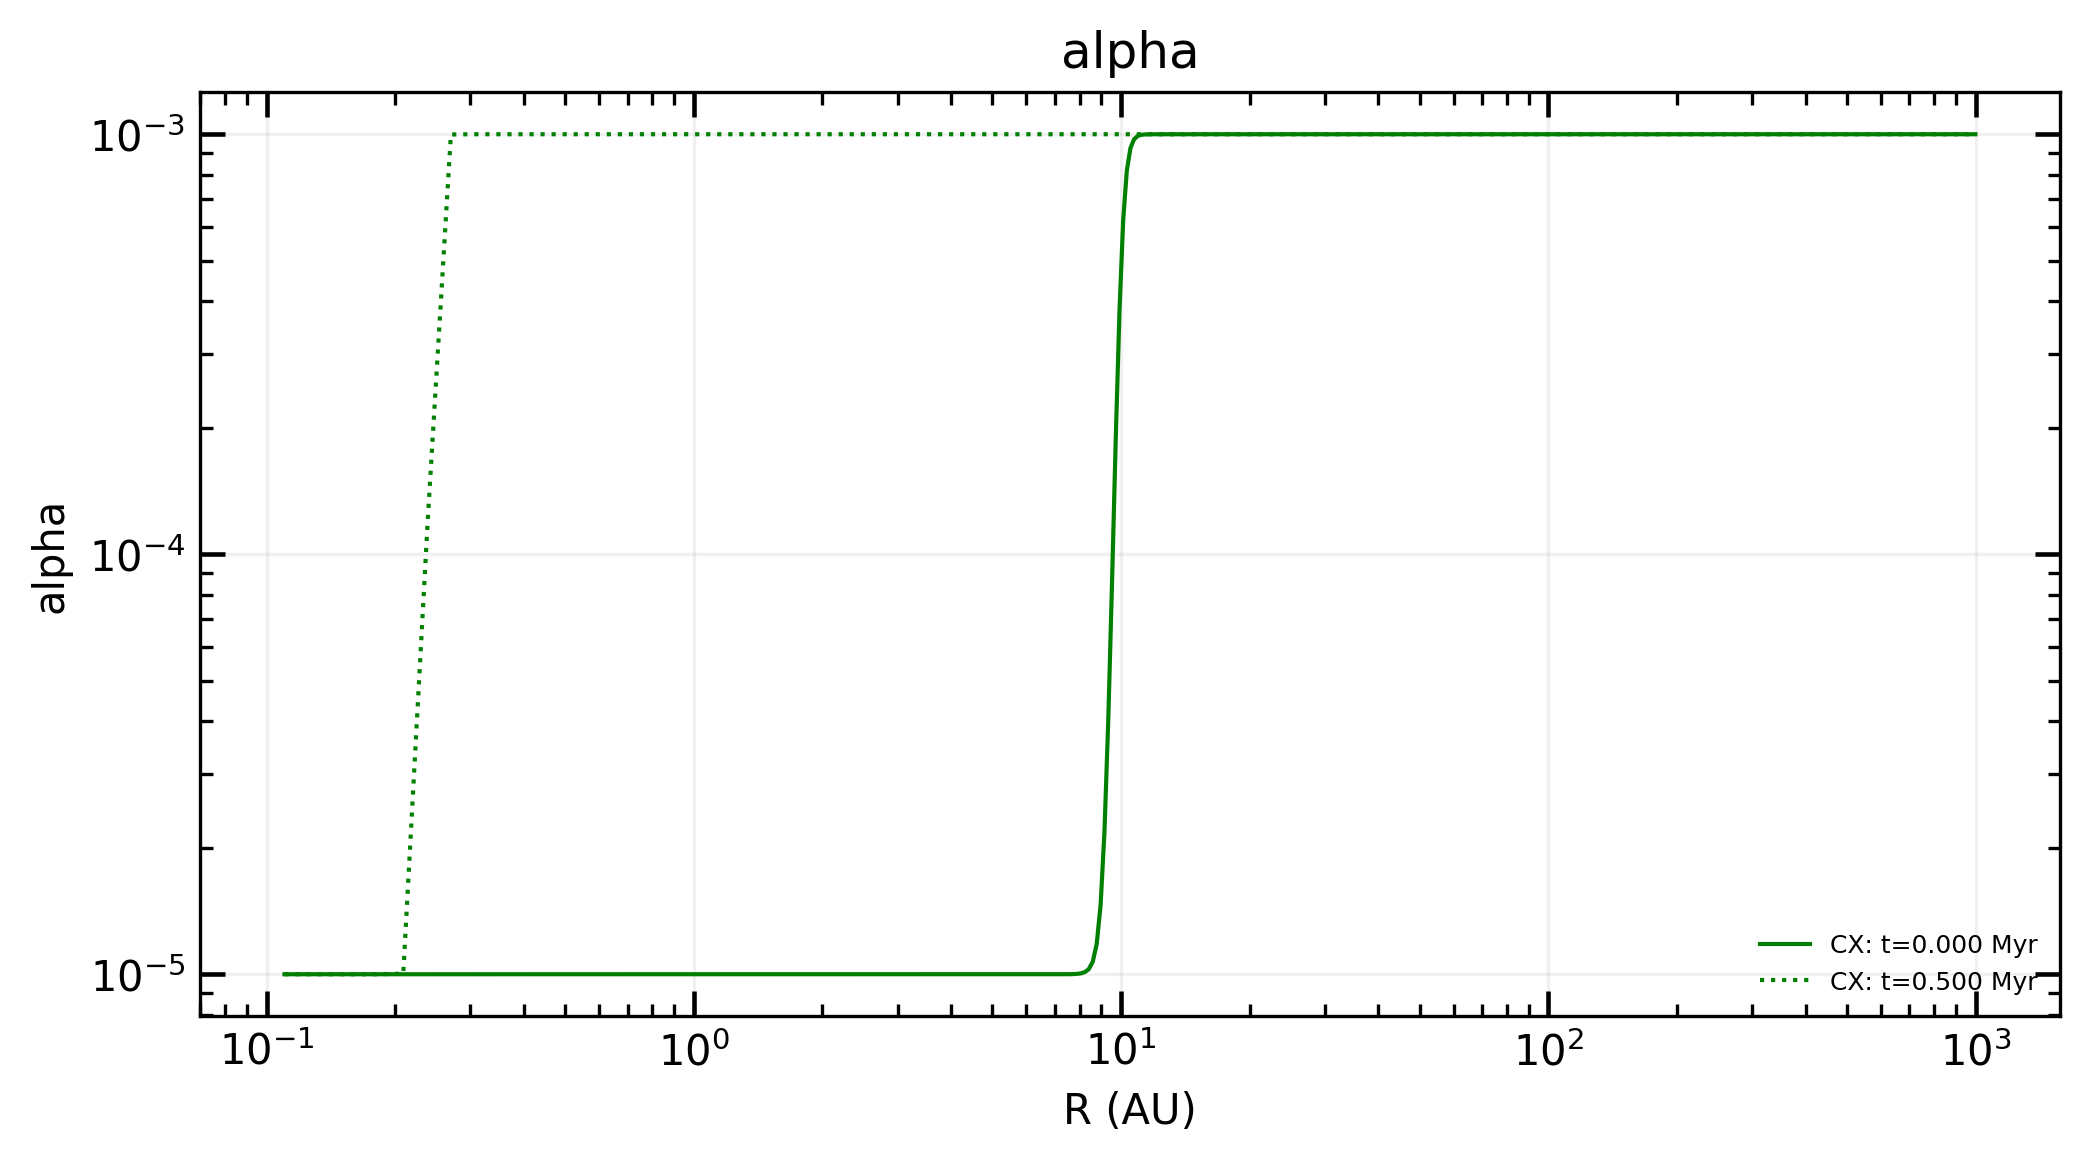

In [23]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('alpha')
plt.title('alpha')
#ax.set_xlim(8,10)
#ax.set_ylim(1e-5,1e-3)

ax.loglog(cxR, cxalpha[0], linestyle='solid', color='green', label=rf"CX: t={cxt[0]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxalpha[-1], linestyle='dotted', color='green', label=rf"CX: t={cxt[-1]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

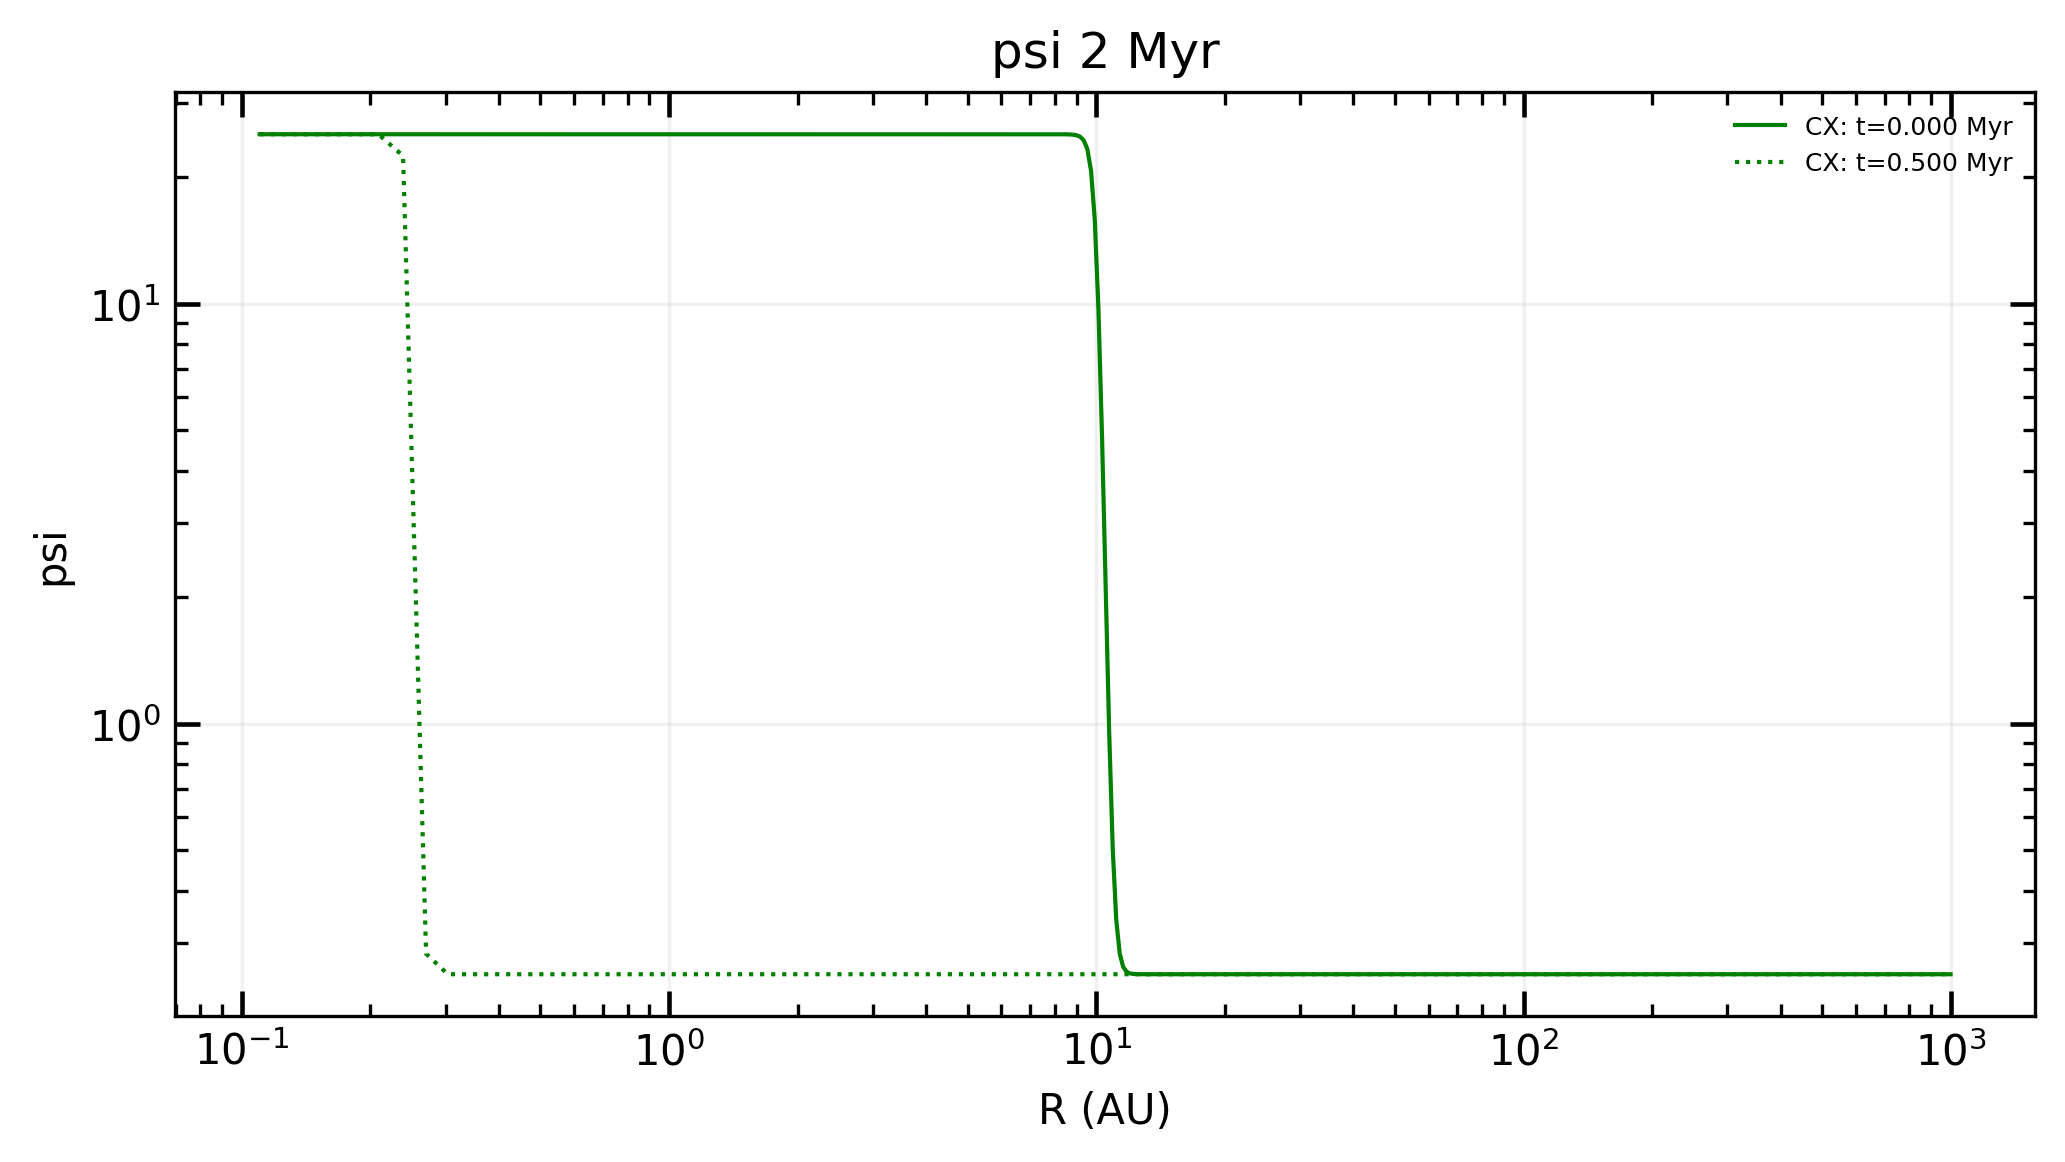

In [24]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('psi')
plt.title('psi 2 Myr')
#ax.set_xlim(8,10)
#ax.set_ylim(1e-5,1e-3)

ax.loglog(cxR, cxpsi[0], linestyle='solid', color='green', label=rf"CX: t={cxt[0]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxpsi[-1], linestyle='dotted', color='green', label=rf"CX: t={cxt[-1]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

# M dot

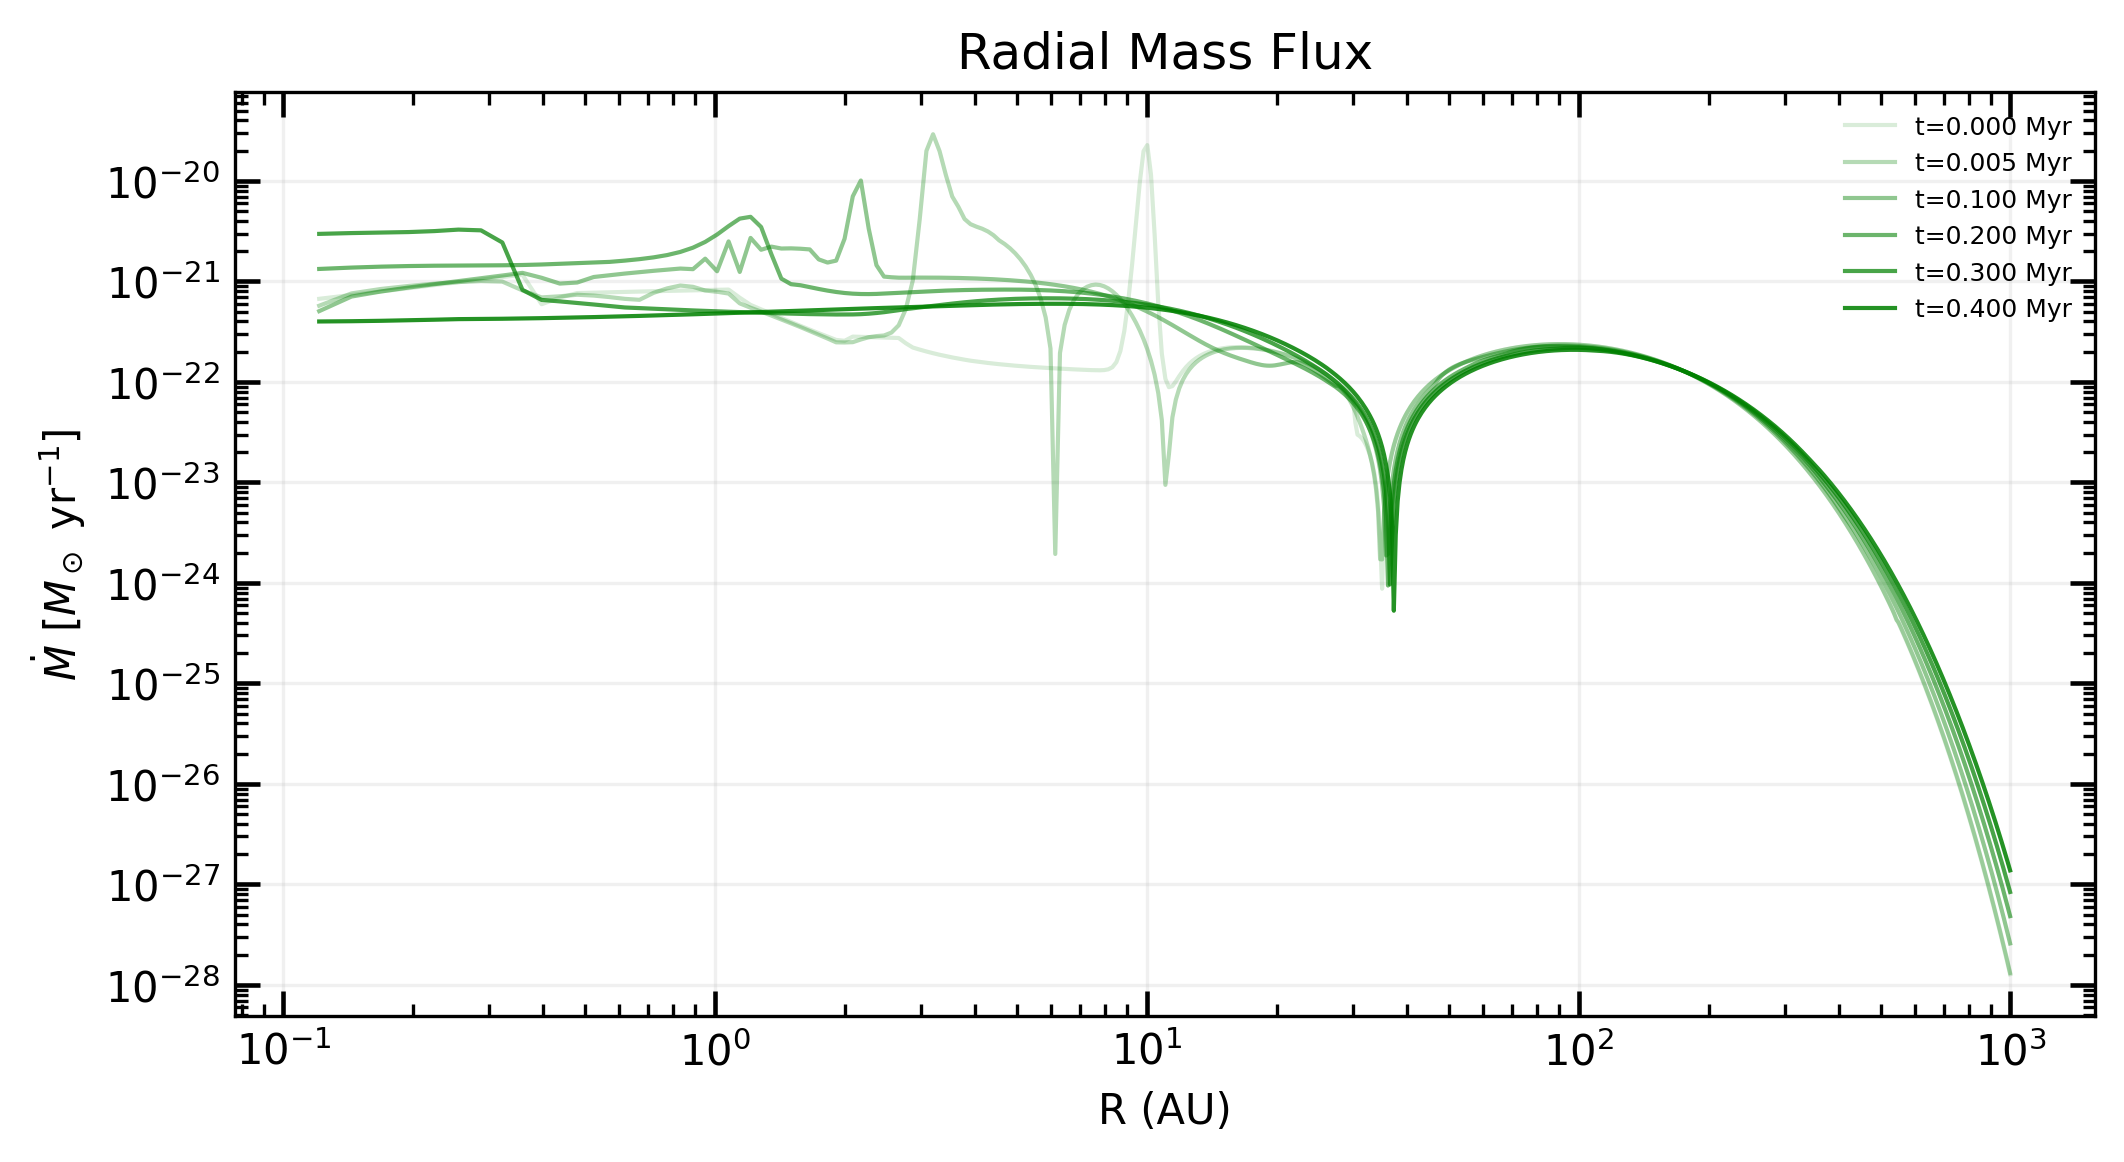

In [25]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel(r'$\dot{M}$ [$M_\odot$ yr$^{-1}$]')
ax.set_title('Radial Mass Flux')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = cxR_faces
ydata = cxMdot_r
for a_i, i in enumerate(range(0,6)):
    ax.loglog(xdata, np.abs(ydata[i]), linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"t={cxtsnap[i]:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

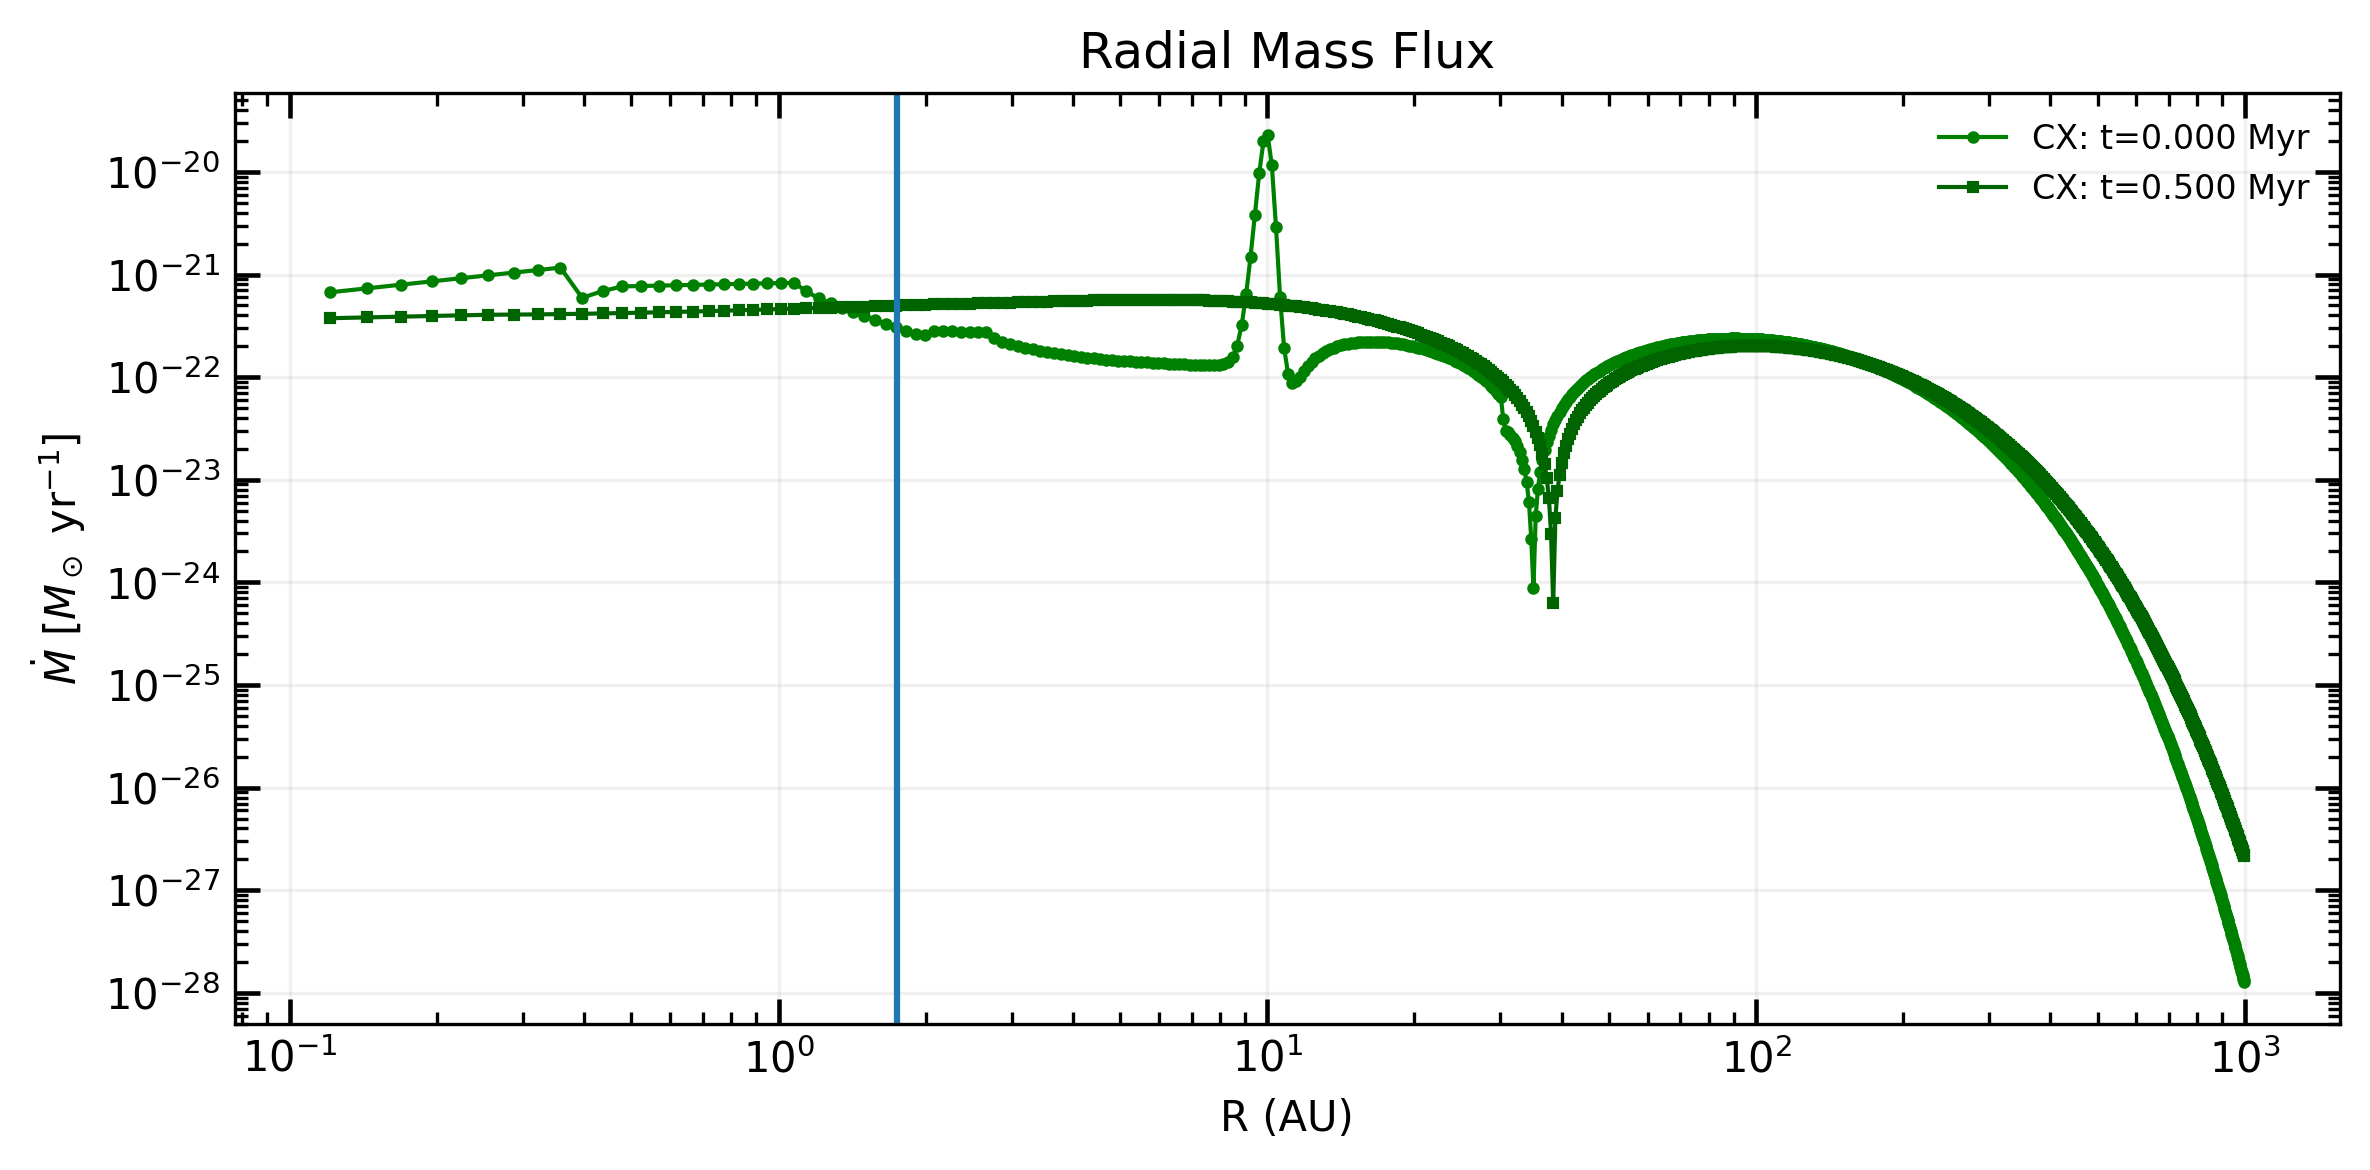

In [27]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel(r'$\dot{M}$ [$M_\odot$ yr$^{-1}$]')
ax.set_title('Radial Mass Flux')

ax.loglog(cxR_faces, np.abs(cxMdot_r[0]), 'o-', color='green', label=f'CX: t={cxt[0]/1e6:.3f} Myr', ms=2, lw=1)
ax.loglog(cxR_faces, np.abs(cxMdot_r[-1]), 's-', color='darkgreen', label=f'CX: t={cxt[-1]/1e6:.3f} Myr', ms=2, lw=1)

ax.axvline(1.75)
ax.axhline(0, color='k', linestyle=':', lw=0.8)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## Test Tolerance Function Without Simulation

Test the `_find_deadzone_radius()` method with synthetic Lambda profiles.

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from DiscEvolution.eos import DeadZoneEOS
from DiscEvolution.star import SimpleStar
from DiscEvolution.grid import Grid
from DiscEvolution.opacity import Zhu2012

# Create a minimal DeadZoneEOS instance just for testing the tolerance function
star = SimpleStar(M=1.0, R=2.5, T_eff=4000)
grid = Grid(0.1, 1000, 1000)  # Small grid for testing

# Initialize DeadZoneEOS with minimal required parameters
eos_test = DeadZoneEOS(
    star,
    psi=1.0,
    Mdot=1e-8,
    alpha_guess=1e-5,  # Required parameter
    evolution_model='static',  # Static model for testing
    kappa=Zhu2012,
    warm_start=False
)
eos_test.set_grid(grid)

print("DeadZoneEOS initialized for testing")
print(f"Grid: {len(grid.Rc)} cells from {grid.Rc[0]:.2f} to {grid.Rc[-1]:.1f} AU")

DeadZoneEOS initialized for testing
Grid: 1000 cells from 0.10 to 995.4 AU


In [96]:
# Test Case 1: Perfect monotonic profile (increasing with radius)
# Inner regions: low Lambda (dead), Outer regions: high Lambda (active)
R_test = np.linspace(0.1, 100, 100)
Lambda_mono = 0.525 * (1 + np.tanh((R_test - 5) / 2))  # Smooth S-curve: ranges ~0 to ~1.1

tol0 = 1e-3
Rdz_mono = eos_test._find_deadzone_radius(R_test, Lambda_mono, tol=tol0)
print(f"Test 1 - Monotonic profile (dead inner, active outer):")
print(f"  Rdz = {Rdz_mono:.3f} AU")
print(f"  Lambda at Rdz = {np.interp(Rdz_mono, R_test, Lambda_mono):.4f} (should be ~1.0)")
print(f"  Lambda at inner edge (R={R_test[0]:.1f} AU) = {Lambda_mono[0]:.4f}")
print(f"  Lambda at outer edge (R={R_test[-1]:.1f} AU) = {Lambda_mono[-1]:.4f}\n")

Test 1 - Monotonic profile (dead inner, active outer):
  Rdz = 8.054 AU
  Lambda at Rdz = 1.0000 (should be ~1.0)
  Lambda at inner edge (R=0.1 AU) = 0.0078
  Lambda at outer edge (R=100.0 AU) = 1.0500



In [116]:
# Test Case 2: Non-monotonic with oscillations (still increasing overall)
# Add wiggles around the main trend while preserving dead→active transition
Lambda_wiggly = 0.525 * (1 + np.tanh((R_test - 5) / 2)) + 0.1 * np.sin(8 * R_test)

tol1 = 1e-2
Rdz_wiggly = eos_test._find_deadzone_radius(R_test, Lambda_wiggly, tol=tol1)
print(f"Test 2 - Wiggly profile (tol={tol1}):")
print(f"  Rdz = {Rdz_wiggly:.3f} AU")
print(f"  Lambda at Rdz = {np.interp(Rdz_wiggly, R_test, Lambda_wiggly):.4f}\n")

# Test with stricter tolerance
tol2 = 3e-2
Rdz_wiggly_strict = eos_test._find_deadzone_radius(R_test, Lambda_wiggly, tol=tol2)
print(f"Test 2b - Same profile (tol={tol2}, stricter):")
print(f"  Lambda at Rdz = {np.interp(Rdz_wiggly_strict, R_test, Lambda_wiggly):.4f}\n")
print(f"  Rdz = {Rdz_wiggly_strict:.3f} AU\n")

Test 2 - Wiggly profile (tol=0.01):
  Rdz = 7.127 AU
  Lambda at Rdz = 1.0000

Test 2b - Same profile (tol=0.03, stricter):
  Lambda at Rdz = 1.0000

  Rdz = 13.467 AU



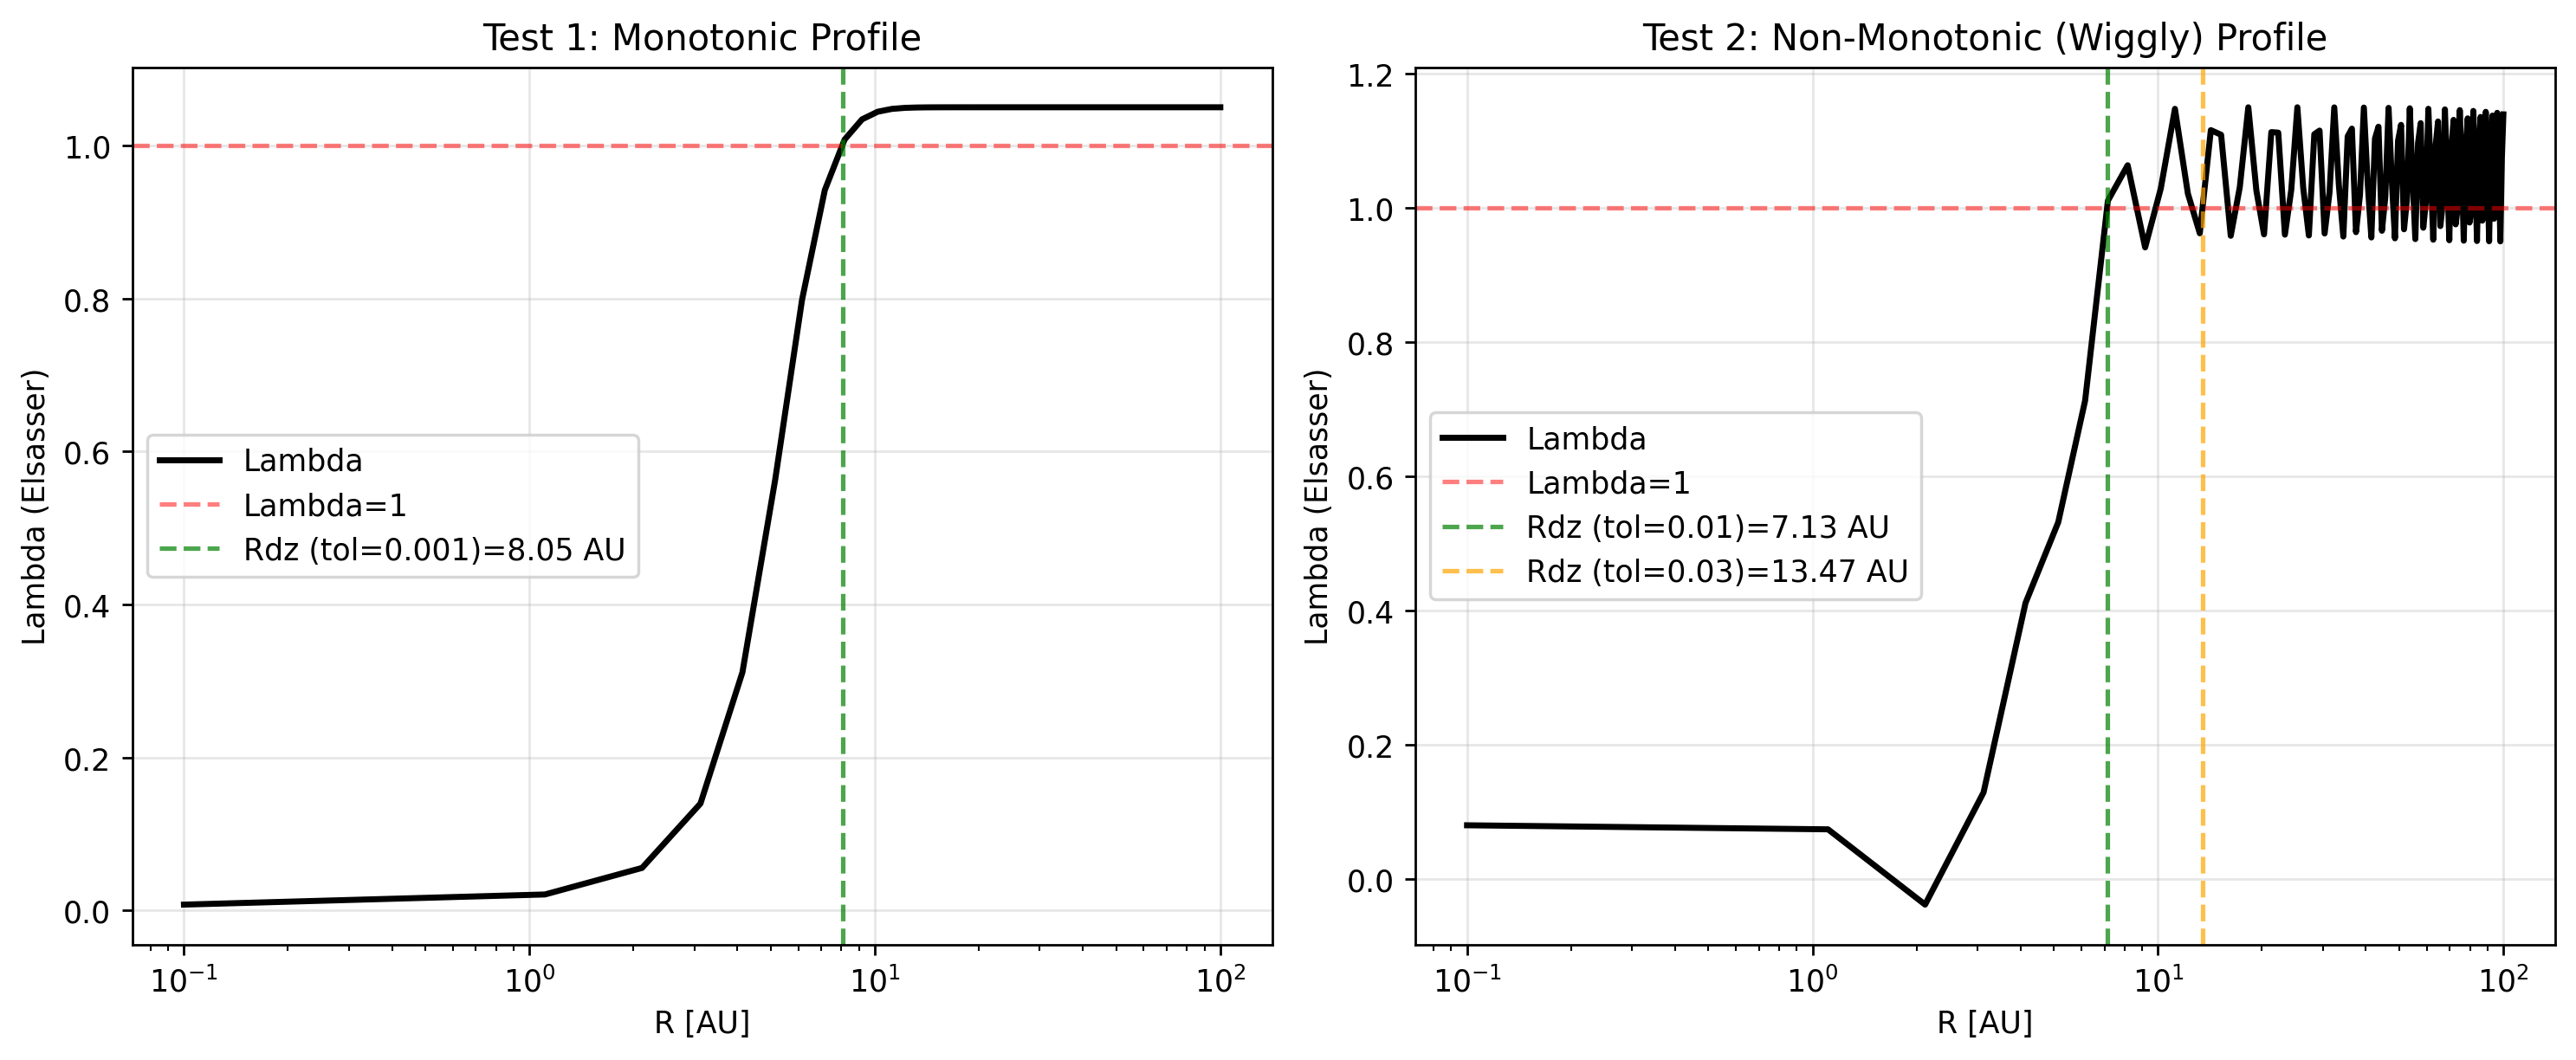

In [117]:
# Visualize the test cases
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi = 250)

# Test 1: Monotonic
ax = axes[0]
ax.semilogx(R_test, Lambda_mono, 'k-', linewidth=2, label='Lambda')
ax.axhline(1, color='r', linestyle='--', alpha=0.5, label='Lambda=1')
ax.axvline(Rdz_mono, color='g', linestyle='--', alpha=0.7, label=f'Rdz (tol={tol0})={Rdz_mono:.2f} AU')
ax.set_xlabel('R [AU]')
ax.set_ylabel('Lambda (Elsasser)')
ax.set_title('Test 1: Monotonic Profile')
ax.legend()
ax.grid(True, alpha=0.3)

# Test 2: Wiggly
ax = axes[1]
ax.semilogx(R_test, Lambda_wiggly, 'k-', linewidth=2, label='Lambda')
ax.axhline(1, color='r', linestyle='--', alpha=0.5, label='Lambda=1')
ax.axvline(Rdz_wiggly, color='g', linestyle='--', alpha=0.7, label=f'Rdz (tol={tol1})={Rdz_wiggly:.2f} AU')
ax.axvline(Rdz_wiggly_strict, color='orange', linestyle='--', alpha=0.7, label=f'Rdz (tol={tol2})={Rdz_wiggly_strict:.2f} AU')
ax.set_xlabel('R [AU]')
ax.set_ylabel('Lambda (Elsasser)')
ax.set_title('Test 2: Non-Monotonic (Wiggly) Profile')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [166]:
L = cxLam
R = cxR
tol_comp = 0.3

for i, _ in enumerate(cxidx):
    Rdz = eos_test._find_deadzone_radius(cxR, cxLam[i], tol=tol_comp)
    print(f"t={cxt[i]/1e6:.3f} Myr: (tol = {tol_comp}) Computed Rdz = {Rdz:.3f} AU, (tol=1e-2) Stored Rdz = {cxRdz[i]:.3f} AU")

t=0.000 Myr: (tol = 0.3) Computed Rdz = 0.110 AU, (tol=1e-2) Stored Rdz = 4.241 AU
t=0.001 Myr: (tol = 0.3) Computed Rdz = 0.110 AU, (tol=1e-2) Stored Rdz = 4.105 AU
t=0.001 Myr: (tol = 0.3) Computed Rdz = 4.002 AU, (tol=1e-2) Stored Rdz = 4.002 AU
t=0.002 Myr: (tol = 0.3) Computed Rdz = 3.883 AU, (tol=1e-2) Stored Rdz = 3.883 AU
t=0.002 Myr: (tol = 0.3) Computed Rdz = 0.110 AU, (tol=1e-2) Stored Rdz = 3.838 AU
t=0.003 Myr: (tol = 0.3) Computed Rdz = 0.110 AU, (tol=1e-2) Stored Rdz = 3.734 AU
t=0.003 Myr: (tol = 0.3) Computed Rdz = 0.110 AU, (tol=1e-2) Stored Rdz = 3.740 AU


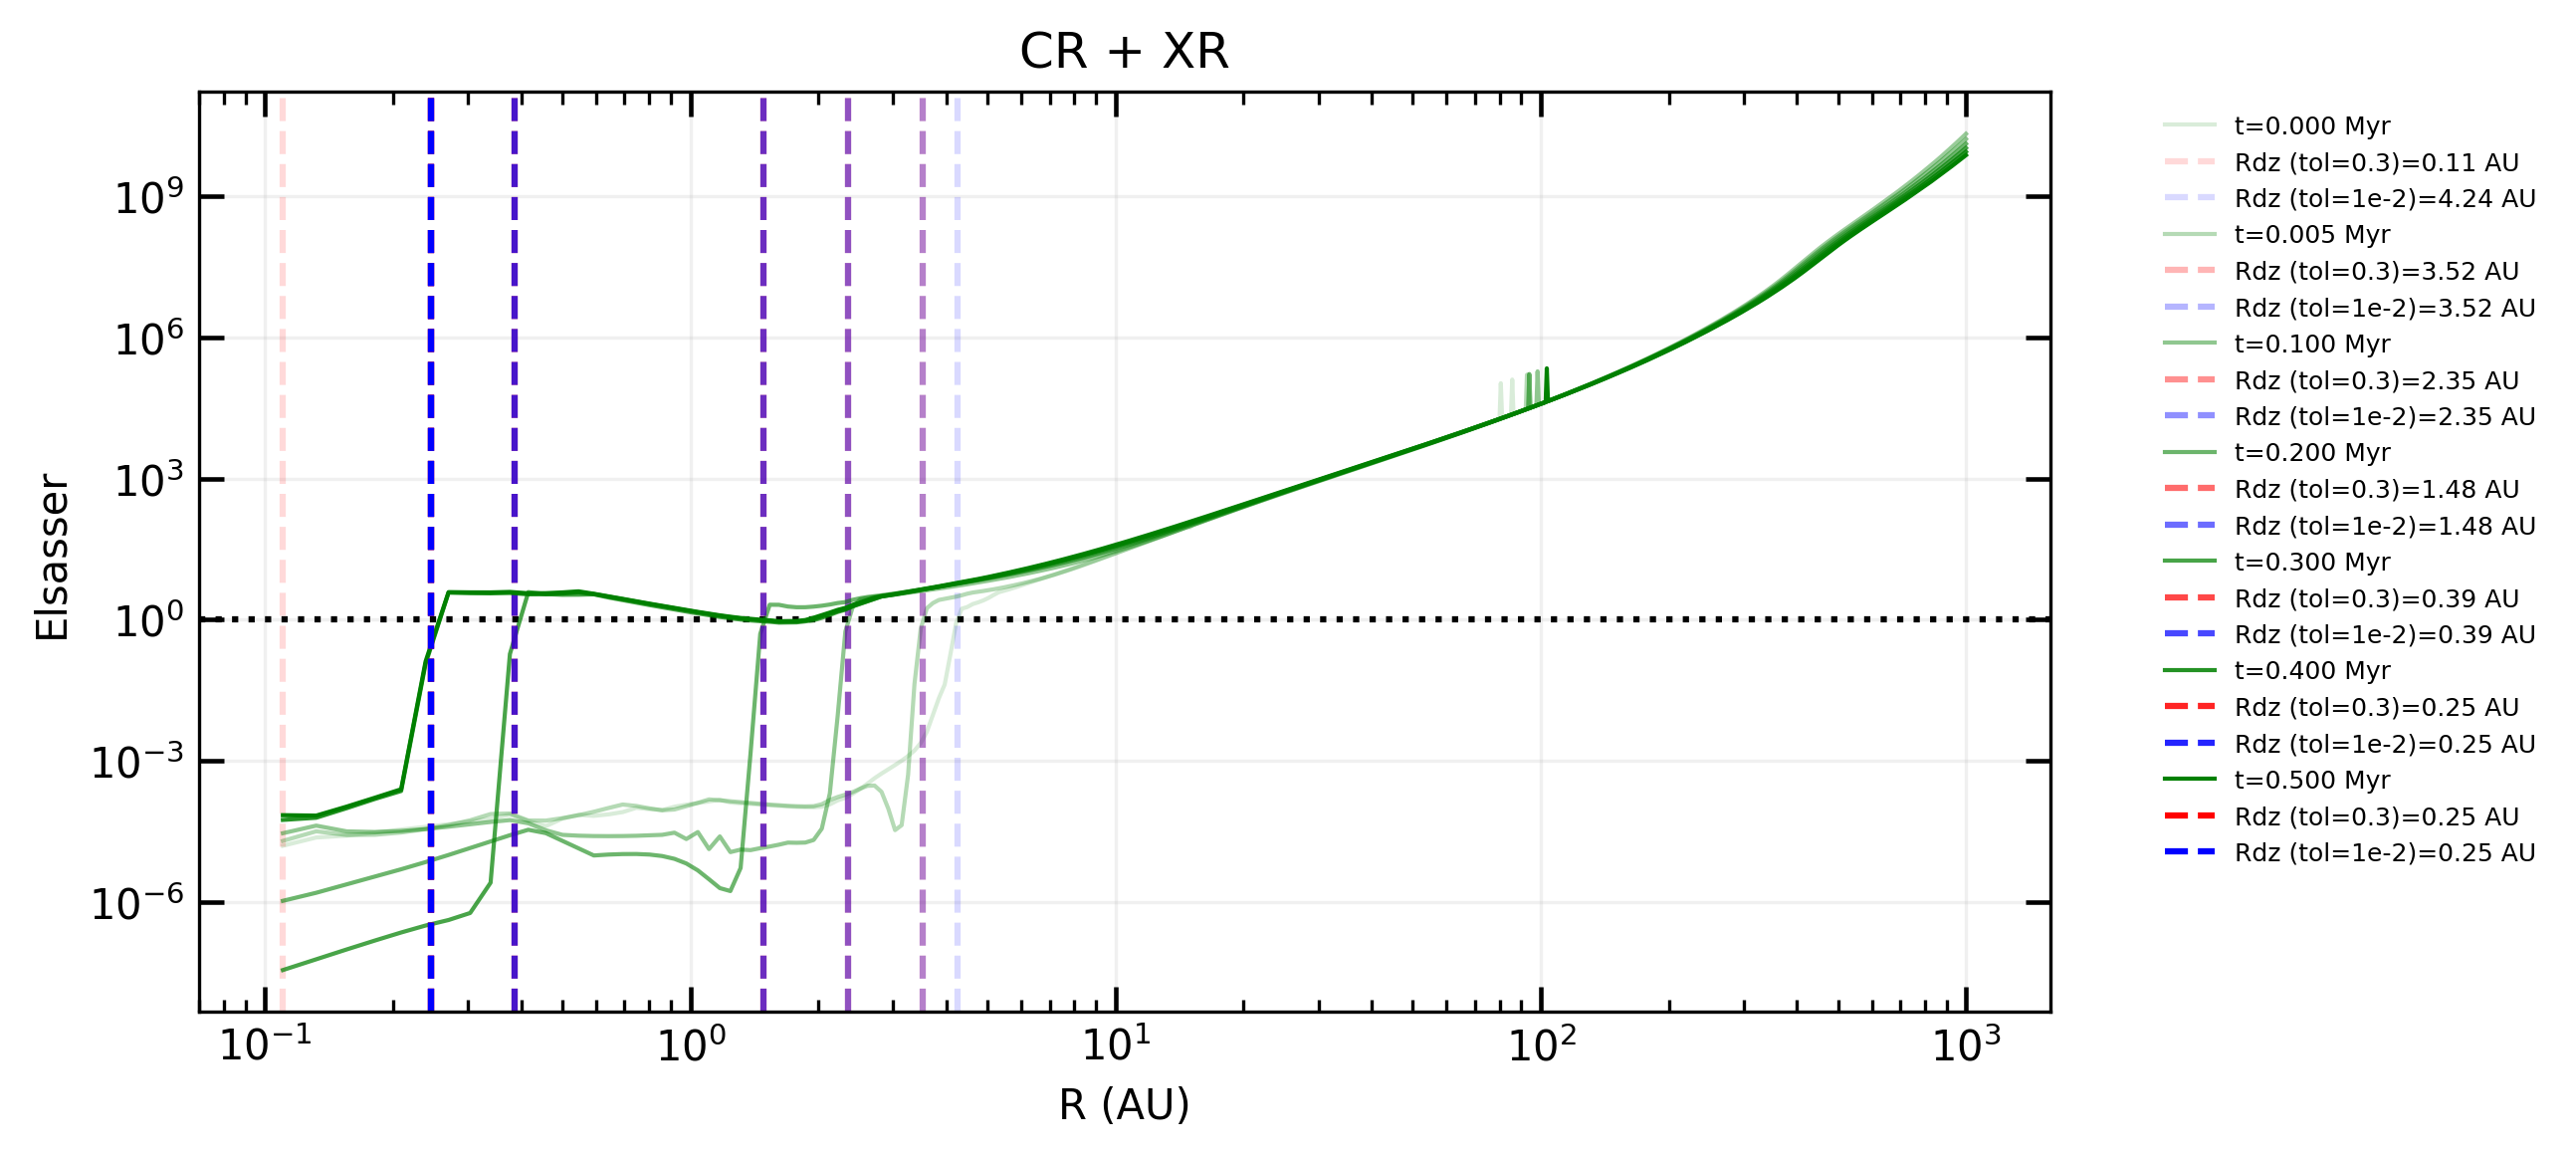

In [167]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Elsasser')
plt.title('CR + XR')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)
ax.axhline(y = 1.0, color = 'black', ls = 'dotted')

xdata = cxR
ydata = cxLam
for a_i, i in enumerate(cxidx):
    Rdz = eos_test._find_deadzone_radius(cxR, cxLam[i], tol=tol_comp)
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"t={cxt[i]/1e6:.3f} Myr", lw = 1.0)
    ax.axvline(Rdz, color='red', linestyle='--', alpha=alphas[a_i], label=f'Rdz (tol={tol_comp})={Rdz:.2f} AU')
    ax.axvline(cxRdz[i], color='blue', linestyle='--', alpha=alphas[a_i], label=f'Rdz (tol=1e-2)={cxRdz[i]:.2f} AU')

ax.legend(frameon=False, fontsize=6, bbox_to_anchor=(1.05, 1.0), loc='upper left')

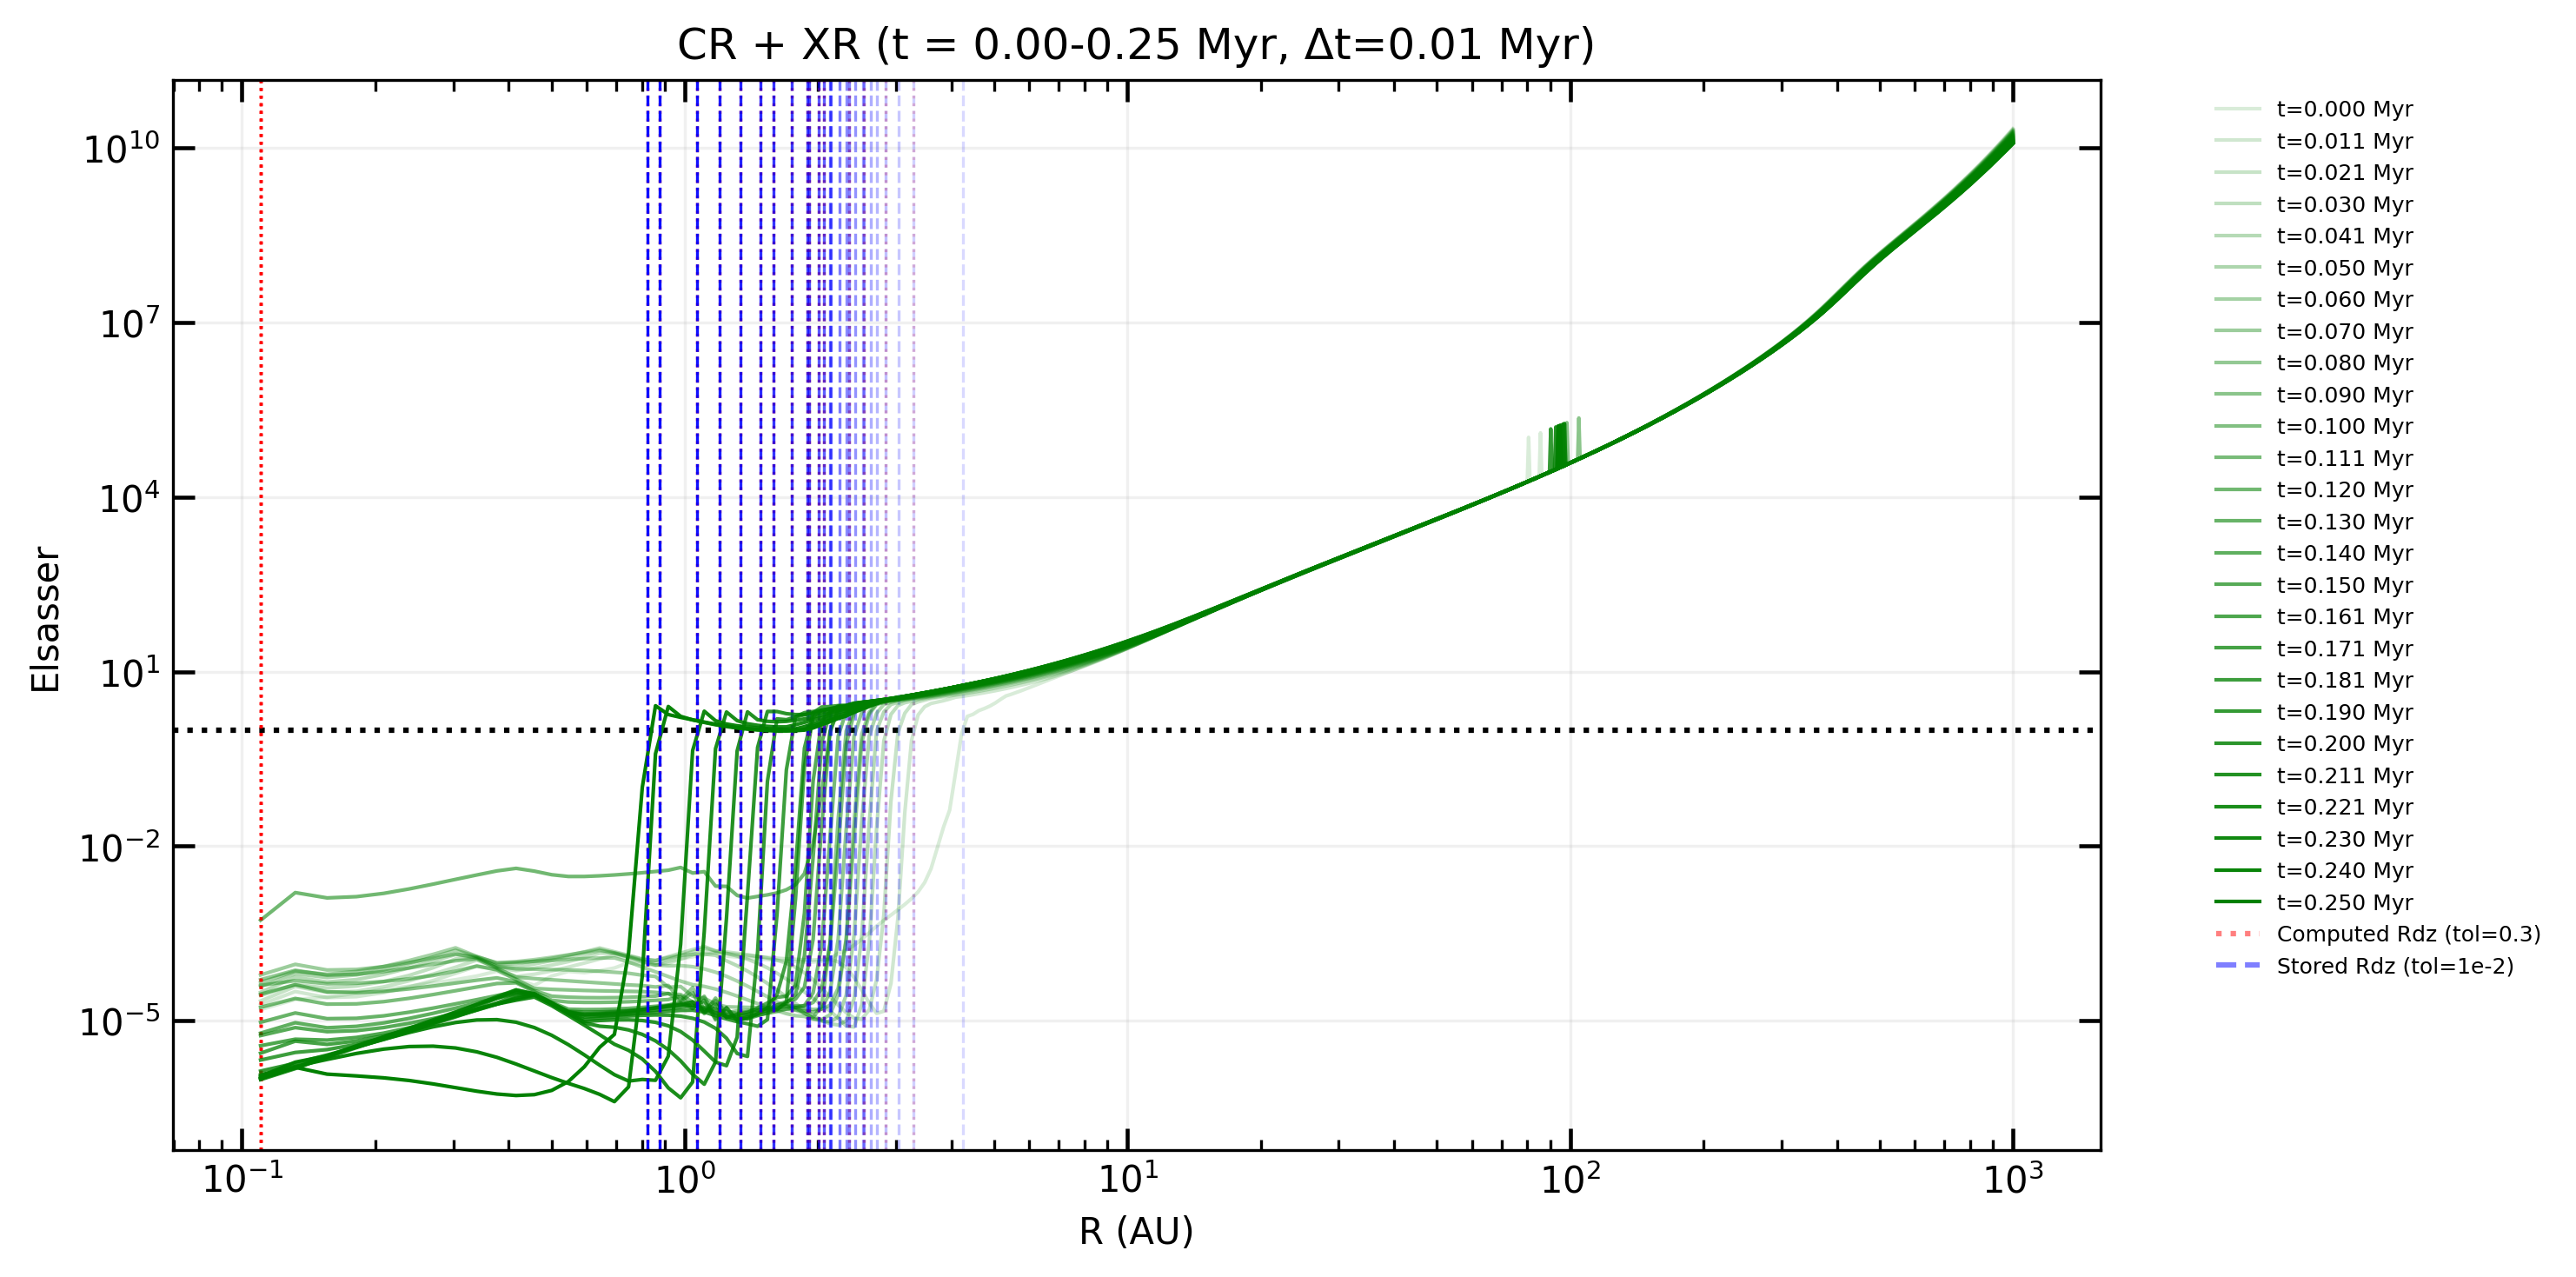

In [180]:
time_min = 0.0  # Myr
time_max = 0.25  # Myr
time_step = 0.01  # Myr

# Create array of desired times in years
times_myr = np.arange(time_min, time_max + time_step/2, time_step)
times_yr = times_myr * 1e6

# Find closest index in cxt for each desired time
sampled_idx = np.searchsorted(cxt, times_yr)
sampled_idx = np.clip(sampled_idx, 0, len(cxt) - 1)

# Double-check we're within range
mask = (cxt[sampled_idx] >= times_yr[0]) & (cxt[sampled_idx] <= times_yr[-1] + time_step*1e6)
sampled_idx = sampled_idx[mask]
times_myr_actual = cxt[sampled_idx] / 1e6

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
alphas = np.linspace(0.15, 1.0, len(sampled_idx)) if len(sampled_idx) > 1 else [1.0]

ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Elsasser')
plt.title(f'CR + XR (t = {time_min:.2f}-{time_max:.2f} Myr, Δt={time_step:.2f} Myr)')
ax.axhline(y=1.0, color='black', ls='dotted')

xdata = cxR
ydata = cxLam

for a_i, i in enumerate(sampled_idx):
    Rdz = eos_test._find_deadzone_radius(cxR, cxLam[i], tol=tol_comp)
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
              label=rf"t={times_myr_actual[a_i]:.3f} Myr", lw=1.0)
    ax.axvline(Rdz, color='red', linestyle=':', alpha=alphas[a_i], linewidth=0.8)
    ax.axvline(cxRdz[i], color='blue', linestyle='--', alpha=alphas[a_i], linewidth=0.8)

# Add legend entries for the vertical lines
ax.axvline(0, color='red', linestyle=':', alpha=0.5, label=f'Computed Rdz (tol={tol_comp})')
ax.axvline(0, color='blue', linestyle='--', alpha=0.5, label='Stored Rdz (tol=1e-2)')

ax.legend(frameon=False, fontsize=6, bbox_to_anchor=(1.05, 1.0), loc='upper left')
#ax.set_ylim(0.5,1.5)

plt.tight_layout()
plt.show()